In [79]:
# Import modules
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shapereader
%matplotlib inline
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import scipy.signal as ss
from statsmodels.tsa.seasonal import STL
from sklearn.impute import KNNImputer
from scipy.interpolate import interp1d
import math
import glob
import os
import re

In [720]:
# Load the netCDF4 file
ds = xr.open_dataset("200301_202006-C3S-L3_GHG-PRODUCTS-OBS4MIPS-MERGED-v4.3.nc", engine="netcdf4")
# Check the data
ds

<xarray.Dataset> Size: 54MB
Dimensions:                  (time: 210, bnds: 2, lat: 36, lon: 72, pressure: 10)
Coordinates:
  * time                     (time) datetime64[ns] 2kB 2003-01-16T12:00:00 .....
  * lat                      (lat) float64 288B -87.5 -82.5 -77.5 ... 82.5 87.5
  * lon                      (lon) float64 576B -177.5 -172.5 ... 172.5 177.5
Dimensions without coordinates: bnds, pressure
Data variables:
    time_bnds                (time, bnds) datetime64[ns] 3kB ...
    lat_bnds                 (lat, bnds) float64 576B ...
    lon_bnds                 (lon, bnds) float64 1kB ...
    pre                      (pressure) float64 80B ...
    pre_bnds                 (pressure, bnds) float64 160B ...
    land_fraction            (lat, lon) float64 21kB ...
    xch4                     (time, lat, lon) float32 2MB ...
    xch4_nobs                (time, lat, lon) float64 4MB ...
    xch4_stderr              (time, lat, lon) float32 2MB ...
    xch4_stddev              (time, lat, lon) float32 2MB ...
    column_averaging_kernel  (time, pressure, lat, lon) float32 22MB ...
    vmr_profile_ch4_apriori  (time, pressure, lat, lon) float32 22MB ...
Attributes: (12/28)
    activity_id:            obs4MIPs
    comment:                Since long time, climate modellers use ensemble a...
    contact:                Maximilian Reuter (maximilian.reuter@iup.physik.u...
    Conventions:            CF-1.7 ODS-2.1
    creation_date:          2021-02-05T09:48:47Z
    data_specs_version:     2.1.0
    ...                     ...
    source_version_number:  v4.3
    title:                  C3S XCH4 v4.3
    tracking_id:            892d184a-7b35-4bba-836a-94b9cfeb360e
    variable_id:            xch4
    variant_info:           Best Estimate
    variant_label:          BE

In [721]:
ds.xch4

<xarray.DataArray 'xch4' (time: 210, lat: 36, lon: 72)> Size: 2MB
[544320 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 2kB 2003-01-16T12:00:00 ... 2020-06-16
  * lat      (lat) float64 288B -87.5 -82.5 -77.5 -72.5 ... 72.5 77.5 82.5 87.5
  * lon      (lon) float64 576B -177.5 -172.5 -167.5 ... 167.5 172.5 177.5
Attributes:
    standard_name:  dry_atmosphere_mole_fraction_of_methane
    long_name:      column-average dry-air mole fraction of atmospheric methane
    units:          1
    cell_methods:   time: mean
    fill_value:     1e+20
    comment:        Satellite retrieved column-average dry-air mole fraction ...

In [722]:
ds.xch4.head()

<xarray.DataArray 'xch4' (time: 5, lat: 5, lon: 5)> Size: 500B
[125 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 40B 2003-01-16T12:00:00 ... 2003-05-16T12:...
  * lat      (lat) float64 40B -87.5 -82.5 -77.5 -72.5 -67.5
  * lon      (lon) float64 40B -177.5 -172.5 -167.5 -162.5 -157.5
Attributes:
    standard_name:  dry_atmosphere_mole_fraction_of_methane
    long_name:      column-average dry-air mole fraction of atmospheric methane
    units:          1
    cell_methods:   time: mean
    fill_value:     1e+20
    comment:        Satellite retrieved column-average dry-air mole fraction ...

In [723]:
# Remove missing data
xch41 = ds.xch4.where((ds['xch4'] != 1.000000e+20))

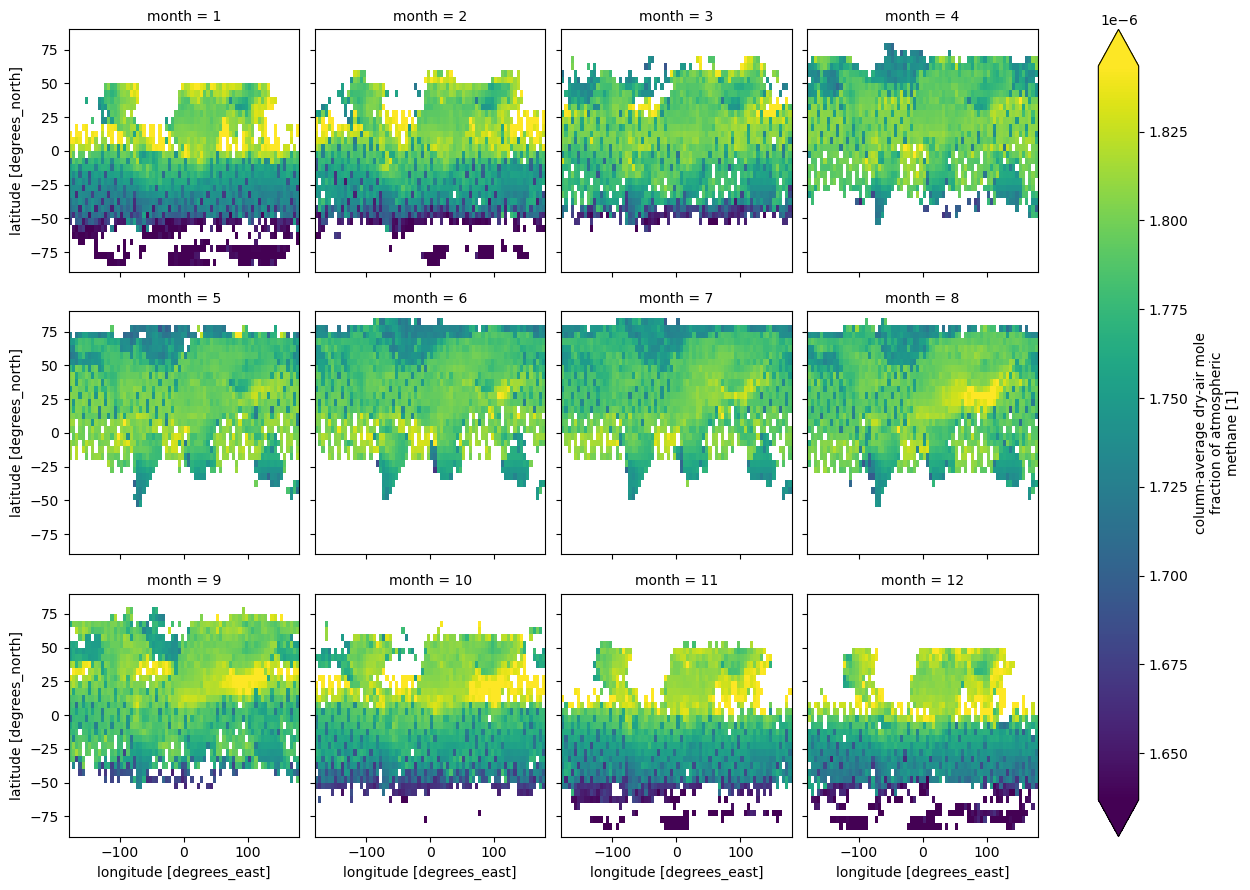

In [724]:
#1.1
xch4_clim = xch41.groupby('time.month')

# Plot monthly mean, one at a panel
xch4_clim.mean(dim='time').plot(col="month", col_wrap=4, robust=True)
plt.show()

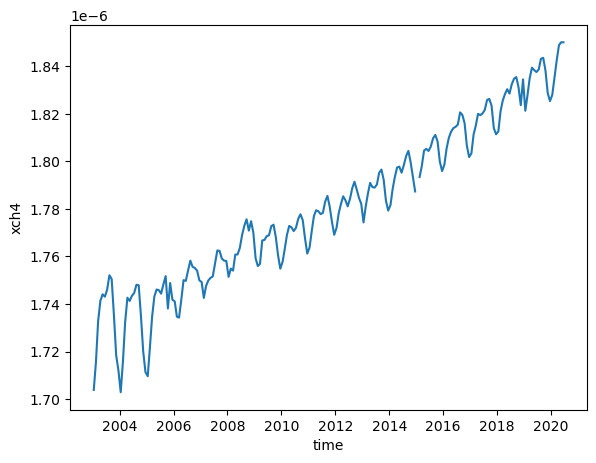

In [725]:
#1.2
ds2 = xch41.mean(dim=['lat','lon'])
ds2.plot(size=5)
plt.show()
#与check plot相近

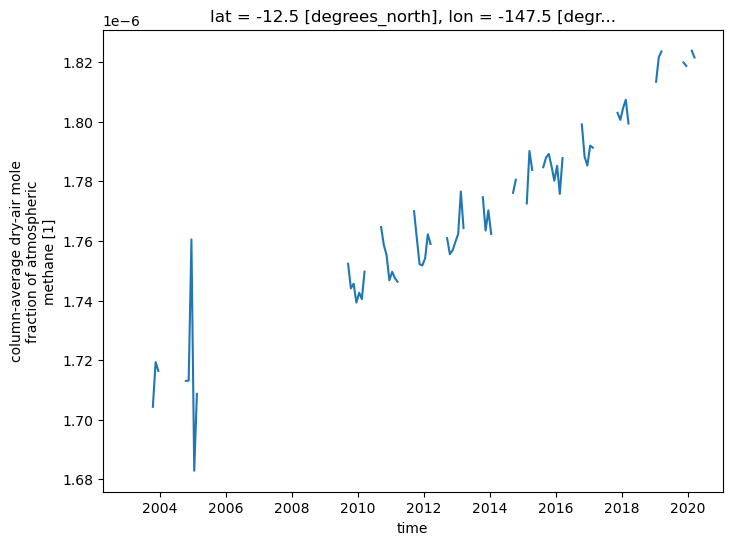

In [726]:
#1.3

#plot含季节性的 methane levels [15°S, 150°W] time series

ds_1=xch41.sel(lon=-150, lat=-15, method='nearest')
ds_1.plot(size=6)
plt.show()

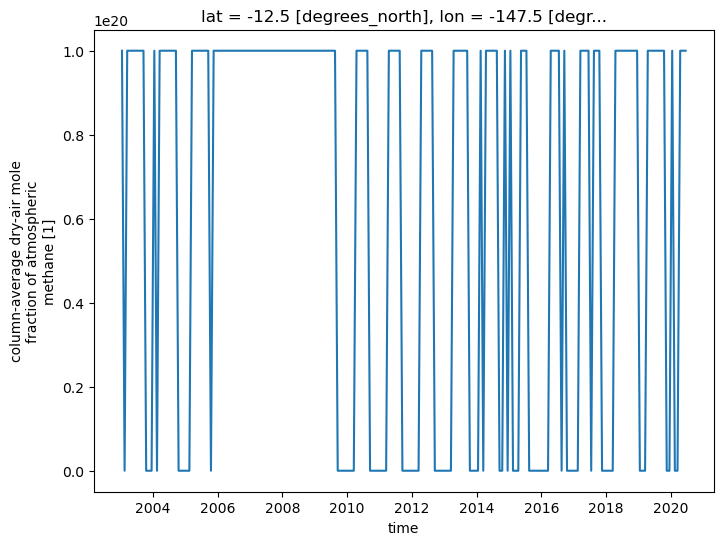

In [727]:
#过滤前数据
ds_2=ds.xch4.sel(lon=-150, lat=-15, method='nearest')
ds_2.plot(size=6)
plt.show()

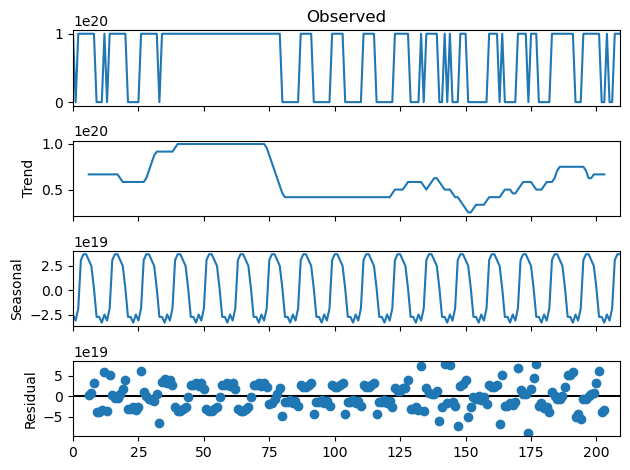

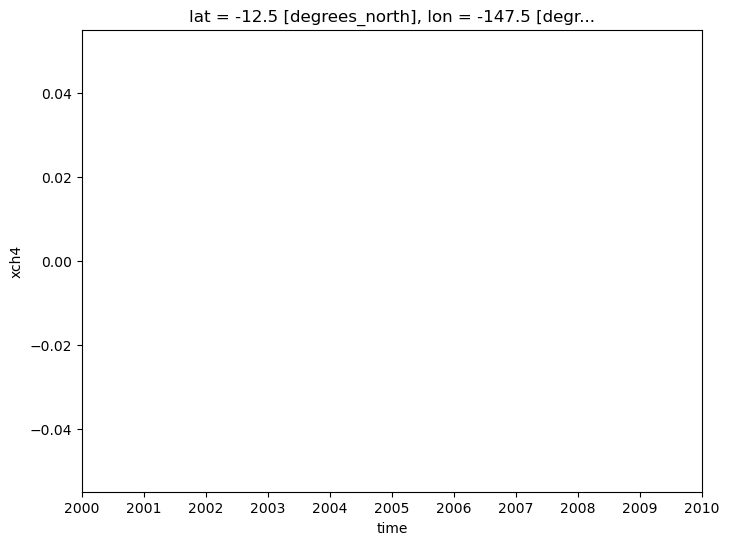

In [728]:
#source: https://cn.bing.com/search?q=python+seasonal+decompose&qs=UT&pq=python+seasonal+de&sc=12-18&cvid=EE6E44AEC2CB429485EBF50C2CB8BFD5&FORM=QBRE&sp=1&lq=0

#一开始想的是，用过滤后的ds_1做seasonal_decompose，但是seasonal_decompose函数要求至少包含两个完整的周期，报错This function does not handle missing values
#decomposition = seasonal_decompose(ds_1, model='additive', period=12, extrapolate_trend=1)
#decomposition.plot()
#plt.show()

#想先对过滤前的数据seasonal_decompose，再用过滤后的减去季节性，但是，用过滤前数据计算出的季节性太大了
#分解时间序列，提取观测季节性
diff = seasonal_decompose(ds_2, model='additive', period=12)
diff.plot()
plt.show()

# 获取趋势、季节性和残差
trend = diff.trend
seasonality = diff.seasonal
residual = diff.resid

#减去季节性
diff2 = ds_1 - seasonality
diff2
diff3 = diff2.where(((diff2 < 1.000000e+15) & (diff2 > -1.000000e+15)))
diff3.plot(size = 6)
plt.show()
#结果无输出，这个方法不可行

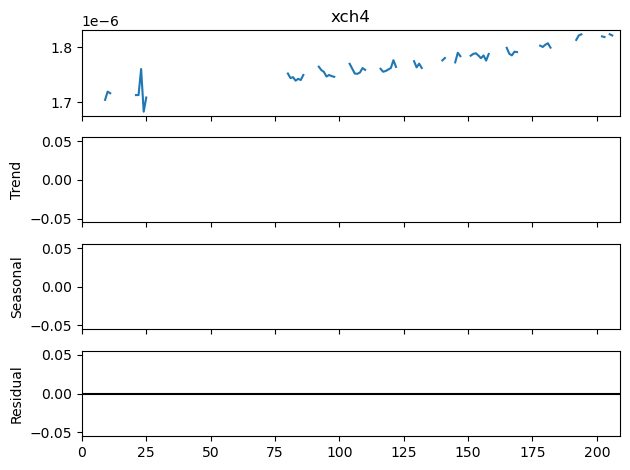

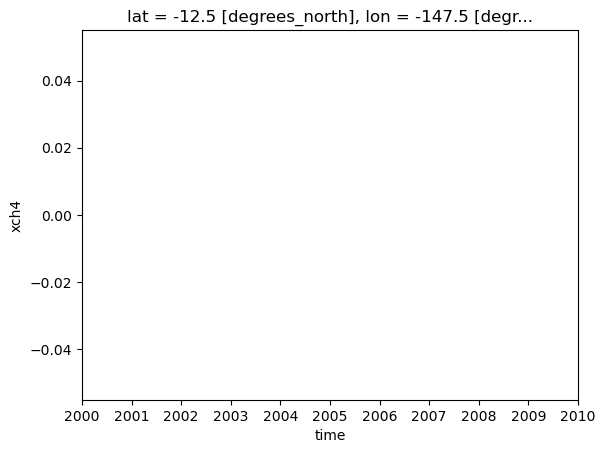

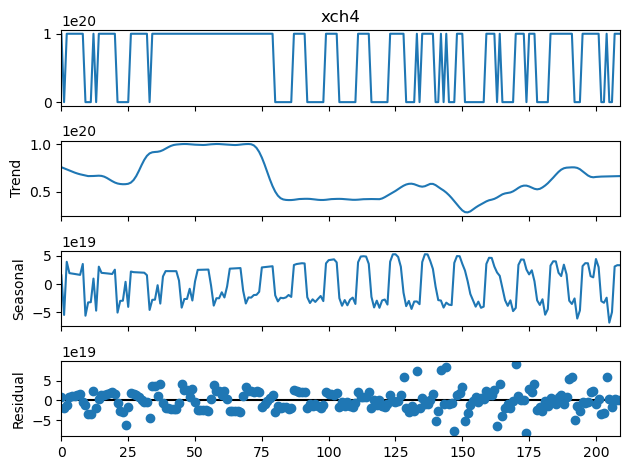

In [729]:
#尝试用stl, 一样的，用过滤后的数据无结果，用过滤前的数据不准 https://blog.csdn.net/weixin_42608414/article/details/126064929?utm_medium=distribute.pc_relevant.none-task-blog-2~default~baidujs_baidulandingword~default-5-126064929-blog-109222247.235^v43^pc_blog_bottom_relevance_base6&spm=1001.2101.3001.4242.4&utm_relevant_index=7
stl = STL(ds_1, seasonal = 13, period = 12)
result1 = stl.fit()
result1.plot()
plt.show()

# 分解结果
trend = result1.trend
seasonal = result1.seasonal
residual = result1.resid


# 4. 去除季节性（原始数据 - 季节性成分）
deseasonalized = ds_1 - seasonal
deseasonalized.plot()
plt.show()

#过滤前数据
stl = STL(ds_2, seasonal = 13, period = 12)
result2 = stl.fit()
result2.plot()
plt.show()

D:\anaconda3\Lib\site-packages\scipy\linalg\_basic.py:1486: RuntimeWarning: overflow encountered in square
  resids = np.sum(np.abs(x[n:])**2, axis=0)


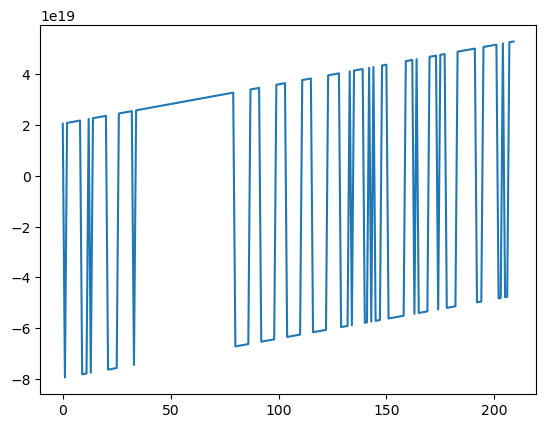

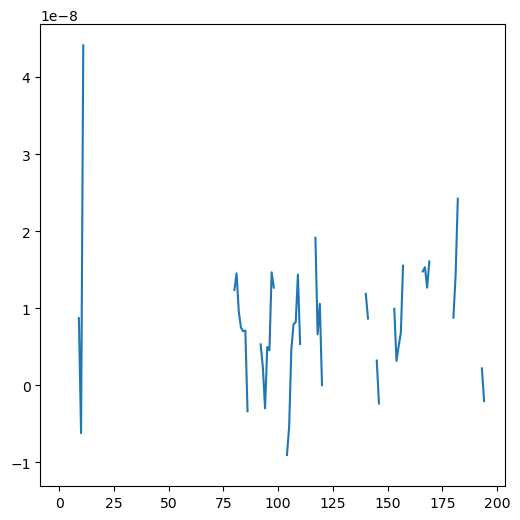

In [730]:
#一些失败的尝试

# 初始化KNN插值器
#imputer = KNNImputer(n_neighbors=1)

# 执行插值
#filled_data = imputer.fit_transform(ds_1)
#print(filled_data.isnull().sum())
#报错

#用detrend source: https://www.bilibili.com/opus/893542996484554820
data_detrend = ss.detrend(ds_2,axis=0)  #---detrend---记得选成时间轴---

plt.plot(data_detrend)
plt.show()
#。。。好像获得了相反的数据
#Detrend是去掉趋势

#尝试用差分去掉时间序列的季节性 source: https://blog.csdn.net/qq_41103204/article/details/105725136

diff = [ds_1[i] - ds_1[i - 12] for i in range(12, len(ds_1))]
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(diff)
plt.show()
#季节性去掉了，但是趋势好像丧失了

=== 原始数据排查 ===
数据形状：(210,)
有效数据数量：77


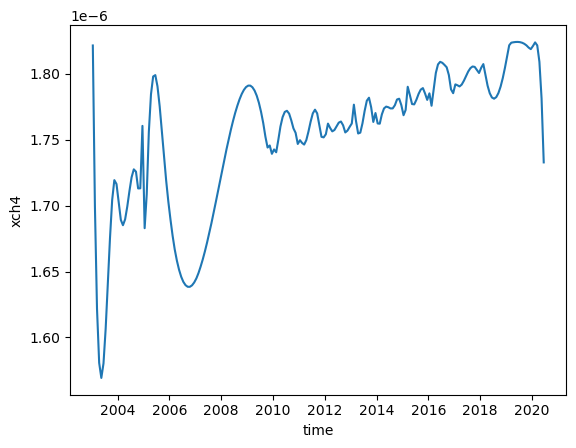


=== 填充结果验证 ===
填充后缺失值数量：<xarray.DataArray 'xch4' ()> Size: 8B
array(0)
填充后数据前5个值：
<xarray.DataArray 'xch4' (time: 5)> Size: 40B
array([1.82151145e-06, 1.69962425e-06, 1.62176314e-06, 1.58072431e-06,
       1.56930395e-06])
Coordinates:
  * time     (time) datetime64[ns] 40B 2003-01-16T12:00:00 ... 2003-05-16T12:...


In [731]:
#只能采用插值补足缺失点 来源：豆包

# 用interpolate_with_extrapolate 插值 source: 豆包
# 1. 排查并预处理原始数据（去重、排序）
print("=== 原始数据排查 ===")
print(f"数据形状：{ds_1.shape}")
print(f"有效数据数量：{np.count_nonzero(~np.isnan(ds_1))}")

# 2. 提取时间索引和数值（转为 numpy 数组，手动处理插值+外推）
time_coords = ds_1.time.values  # 时间坐标（datetime64 类型）
values = ds_1.values  # 数据值（1D 数组）

# 3. 实现“插值+外推”
def interpolate_with_extrapolate(time_coords, values, kind='cubic'):
    # 步骤1：提取非缺失值的索引和数值
    non_nan_idx = np.where(~np.isnan(values))[0]
    non_nan_vals = values[non_nan_idx]
    non_nan_times = time_coords[non_nan_idx]
    
    # 步骤2：生成插值函数（支持外推）
    # 用时间坐标的整数索引做插值（避免 datetime 类型兼容问题）
    f = interp1d(
        non_nan_idx,  # 非缺失值的位置索引（0,1,2,...）
        non_nan_vals,
        kind=kind,
        fill_value="extrapolate",  # scipy 支持直接外推
        bounds_error=False  # 超出范围时不报错，使用外推值
    )
    
    # 步骤3：对所有时间点插值（包括首尾缺失值）
    all_idx = np.arange(len(time_coords))  # 所有数据的位置索引
    filled_vals = f(all_idx)
    
    # 步骤4：转为 DataArray（保持原始结构）
    filled_da = xr.DataArray(
        filled_vals,
        coords={'time': time_coords},
        dims=['time'],
        name=ds_1.name
    )
    return filled_da

# 4. 执行插值+外推（根据有效数据量选择方法）
valid_count = np.count_nonzero(~np.isnan(ds_1.values))
# 有效数据≥3个：用三次插值（更平滑）
filled = interpolate_with_extrapolate(time_coords, values, kind='cubic')
filled.plot()
plt.show()

# 5. 验证填充结果（无空数组、无缺失值）
print("\n=== 填充结果验证 ===")
print(f"填充后缺失值数量：{np.isnan(filled).sum()}")
print(f"填充后数据前5个值：\n{filled.head()}")

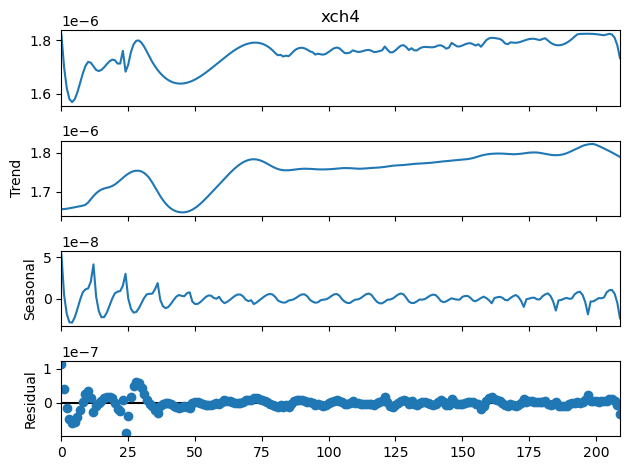

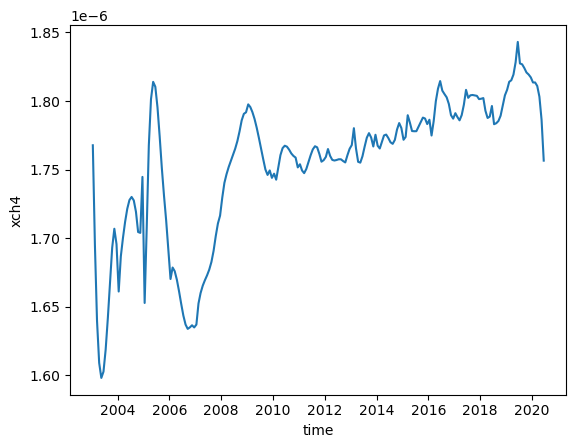

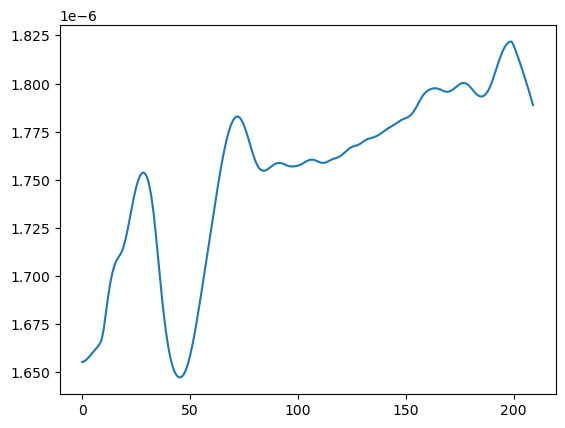

In [732]:
#后续季节性分解（与之前一致）
stl = STL(filled, seasonal = 13, period = 12)
result1 = stl.fit()
result1.plot()
plt.show()

# 分解结果
trend = result1.trend
seasonal = result1.seasonal
residual = result1.resid


# 4. 去除季节性（原始数据 - 季节性成分）
deseasonalized = filled - seasonal
deseasonalized.plot()
plt.show()

#好像不是很平滑，直接用trend
plt.plot(trend)
plt.show() #trend比较平滑

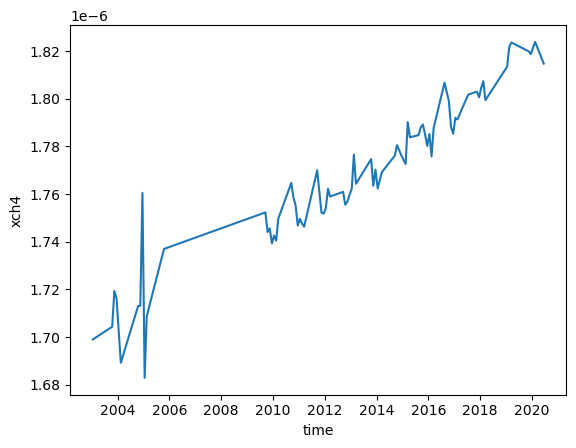

In [733]:
#对于大块缺失部分的插值太不贴合已有趋势了，如果不是用cubic，是用linear线性插值呢？ 
#感觉这里用线性插值得好只是因为缺失部分的线性趋势刚好与整个趋势相近。？。。

# 2. 提取时间索引和数值（转为 numpy 数组，手动处理插值+外推）
time_coords = ds_1.time.values  # 时间坐标（datetime64 类型）
values = ds_1.values  # 数据值（1D 数组）

# 3. 实现“插值+外推”
def interpolate_with_extrapolate(time_coords, values, kind='linear'):
    # 步骤1：提取非缺失值的索引和数值
    non_nan_idx = np.where(~np.isnan(values))[0]
    non_nan_vals = values[non_nan_idx]
    non_nan_times = time_coords[non_nan_idx]
    
    # 步骤2：生成插值函数（支持外推）
    # 用时间坐标的整数索引做插值（避免 datetime 类型兼容问题）
    f = interp1d(
        non_nan_idx,  # 非缺失值的位置索引（0,1,2,...）
        non_nan_vals,
        kind=kind,
        fill_value="extrapolate",  # scipy 支持直接外推
        bounds_error=False  # 超出范围时不报错，使用外推值
    )
    
    # 步骤3：对所有时间点插值（包括首尾缺失值）
    all_idx = np.arange(len(time_coords))  # 所有数据的位置索引
    filled_vals = f(all_idx)
    
    # 步骤4：转为 DataArray（保持原始结构）
    filled_da = xr.DataArray(
        filled_vals,
        coords={'time': time_coords},
        dims=['time'],
        name=ds_1.name
    )
    return filled_da

# 4. 执行插值+外推（根据有效数据量选择方法）
valid_count = np.count_nonzero(~np.isnan(ds_1.values))
# 有效数据≥3个：用三次插值（更平滑）
filled = interpolate_with_extrapolate(time_coords, values, kind='linear')
filled.plot()
plt.show()

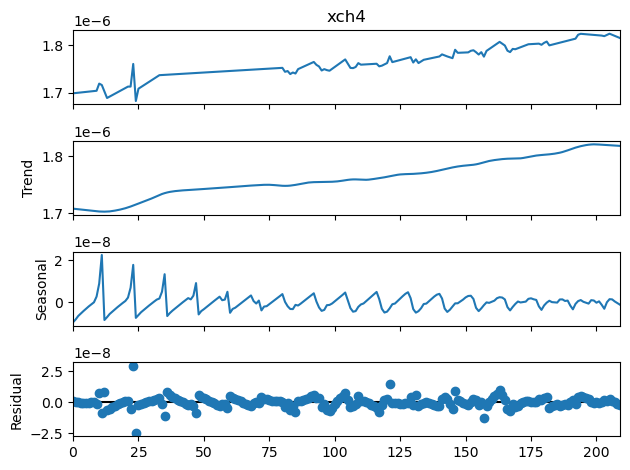

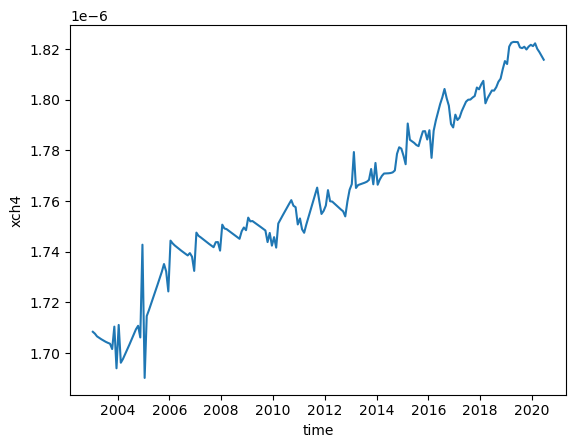

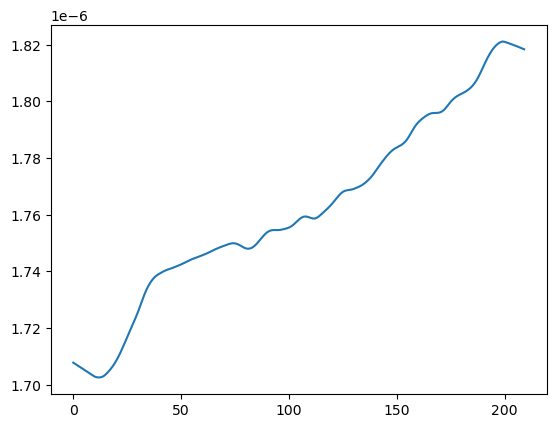

In [734]:
#后续季节性分解（与之前一致）
stl = STL(filled, seasonal = 13, period = 12)
result1 = stl.fit()
result1.plot()
plt.show()

# 分解结果
trend = result1.trend
seasonal = result1.seasonal
residual = result1.resid


# 4. 去除季节性（原始数据 - 季节性成分）
deseasonalized = filled - seasonal
deseasonalized.plot()
plt.show()

#直接用trend
plt.plot(trend)
plt.show()

D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36148 (\N{CJK UNIFIED IDEOGRAPH-8D34}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Li

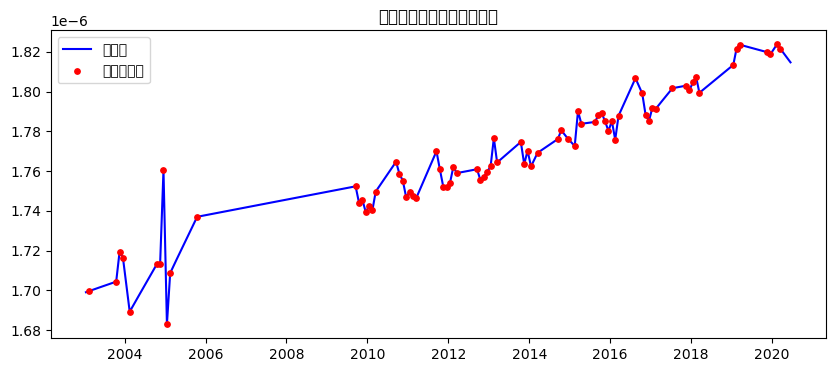


=== 填充结果验证 ===
填充后缺失值数量：0
填充后数据类型：float32
填充后数据前5个值：
<xarray.DataArray 'xch4' (time: 5)> Size: 20B
array([1.6990341e-06, 1.6996242e-06, 1.7002144e-06, 1.7008045e-06,
       1.7013947e-06], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 40B 2003-01-16T12:00:00 ... 2003-05-16T12:...


C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3589364499.py:104: UserWarning: Glyph 25554 (\N{CJK UNIFIED IDEOGRAPH-63D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3589364499.py:104: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3589364499.py:104: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3589364499.py:104: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3589364499.py:104: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3589364499.py:104: UserWarning: Gl

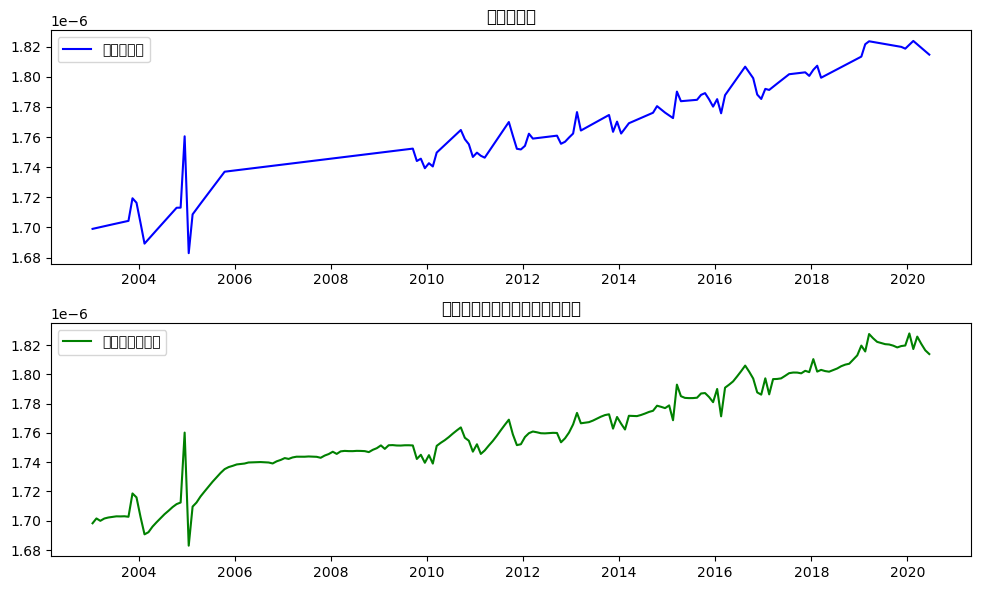

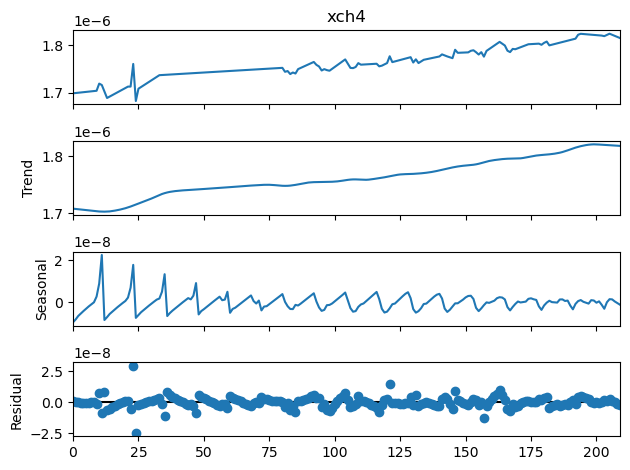

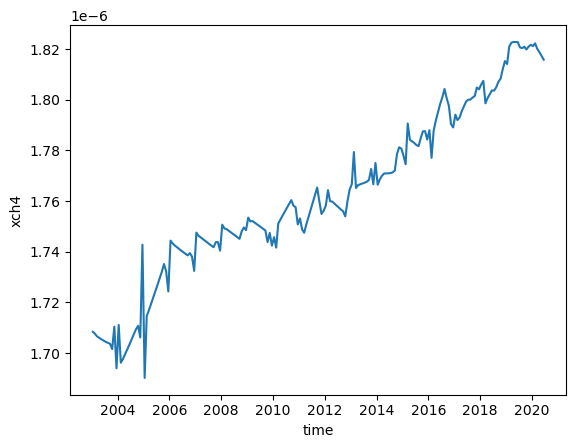

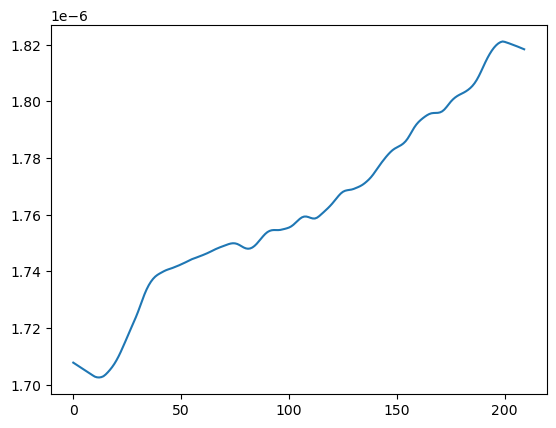

In [735]:
#使用分段线性插值，跟不分段没什么区别 source：豆包

# 2. 提取时间索引和数值（转为 numpy 数组，手动处理插值+外推）
time_coords = ds_1.time.values  # 时间坐标（datetime64 类型）
values = ds_1.values  # 数据值（1D 数组）

# 3. 最终修正版“插值+外推”函数（兼容旧版本xarray，贴合原始有效点）
def interpolate_with_extrapolate(time_coords, values, kind='linear'):
    non_nan_idx = np.where(~np.isnan(values))[0]
    non_nan_vals = values[non_nan_idx]
    
    if len(non_nan_idx) == 0:
        print("警告：原始数据无有效数值，返回原数据！")
        return xr.DataArray(values, coords={'time': time_coords}, dims=['time'], name=ds_1.name)
    
    # 有效点少则强制线性插值
    if len(non_nan_idx) < 3:
        kind = 'linear'
    
    # 生成插值函数
    f = interp1d(
        non_nan_idx,
        non_nan_vals,
        kind=kind,
        fill_value="extrapolate",
        bounds_error=False
    )
    
    all_idx = np.arange(len(time_coords))
    filled_vals = f(all_idx)
    filled_vals[non_nan_idx] = non_nan_vals  # 强制有效点值不变
    
    # 确保填充值是 float32 类型（和原始数据一致，避免类型冲突）
    filled_vals = filled_vals.astype(np.float32)
    
    # 构造 DataArray（旧版本xarray兼容：去掉 dtype 参数，用数组本身类型）
    filled_da = xr.DataArray(
        filled_vals,  # 数组已转为 float32，无需额外指定 dtype
        coords={'time': time_coords},
        dims=['time'],
        name=ds_1.name
    )
    return filled_da

# 4. 执行插值（kind='linear' 贴合有效点）
valid_count = np.count_nonzero(~np.isnan(ds_1.values))
filled = interpolate_with_extrapolate(time_coords, values, kind='linear')

# 可视化：彻底避免类型混合，兼容所有版本
plt.figure(figsize=(10, 4))
# 插值后的数据（蓝色线）：分别取 time.values 和 data.values
plt.plot(filled.time.values, filled.values, label='插值后', color='blue', linewidth=1.5)
# 原始有效点（红色散点）：筛选非缺失值
valid_mask = ~np.isnan(ds_1.values)
plt.scatter(
    ds_1.time[valid_mask].values,  # 时间坐标转为数组
    ds_1.values[valid_mask],       # 数值转为数组
    color='red', label='原始有效点', zorder=3, s=15
)
plt.legend()
plt.title('贴合原始有效点的插值结果')
plt.show()

# 5. 验证填充结果
print("\n=== 填充结果验证 ===")
print(f"填充后缺失值数量：{np.count_nonzero(np.isnan(filled.values))}")
print(f"填充后数据类型：{filled.values.dtype}")
print(f"填充后数据前5个值：\n{filled.head()}")

# 6. 去季节性
from statsmodels.tsa.seasonal import STL

# 关键：根据数据周期修改 period（如月度=12，季度=4，日度=365）
period = 12  # 示例：月度数据，年度周期=12
stl = STL(
    filled.values,  # 传入 numpy 数组，避免 DataArray 类型兼容问题
    period=period,
    seasonal=3*period + 1,  # 增强季节性提取能力
    trend=15,
    robust=True
)
result = stl.fit()

# 构造季节性成分 DataArray
seasonal = xr.DataArray(
    result.seasonal.astype(np.float32),  # 转为和 filled 一致的类型
    coords={'time': filled.time.values},
    dims=['time'],
    name='seasonal'
)
deseasonalized = filled - seasonal

# 可视化去季节性效果
plt.figure(figsize=(10, 6))
plt.subplot(2,1,1)
plt.plot(filled.time.values, filled.values, label='插值后数据', color='blue')
plt.legend()
plt.title('插值后数据')

plt.subplot(2,1,2)
plt.plot(deseasonalized.time.values, deseasonalized.values, label='去季节性后数据', color='green')
plt.legend()
plt.title('去季节性后数据（无残留波动）')
plt.tight_layout()
plt.show()

#后续季节性分解（与之前一致）
stl = STL(filled, seasonal = 13, period = 12)
result1 = stl.fit()
result1.plot()
plt.show()

trend = result1.trend
seasonal = result1.seasonal
residual = result1.resid

deseasonalized = filled - seasonal
deseasonalized.plot()
plt.show()

#直接用trend
plt.plot(trend)
plt.show()

C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3687172808.py:22: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3687172808.py:22: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3687172808.py:22: UserWarning: Glyph 36235 (\N{CJK UNIFIED IDEOGRAPH-8D8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3687172808.py:22: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3687172808.py:22: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3687172808.py:22: UserWarning: Glyph 25

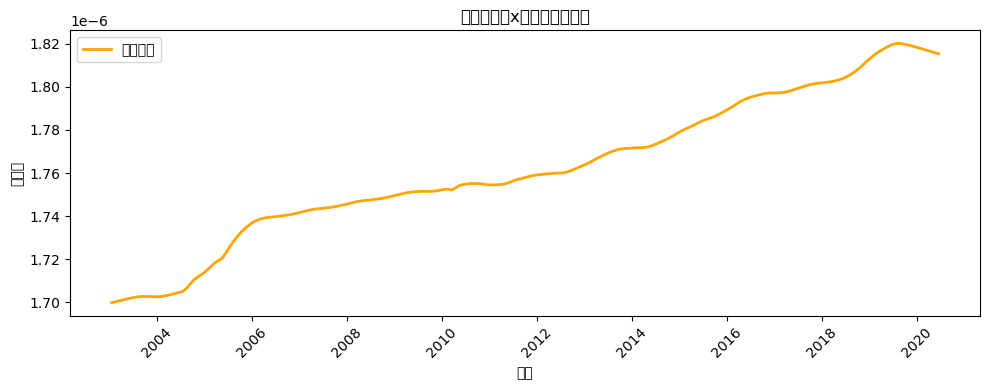

C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3687172808.py:42: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3687172808.py:42: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3687172808.py:42: UserWarning: Glyph 27987 (\N{CJK UNIFIED IDEOGRAPH-6D53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3687172808.py:42: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3687172808.py:42: UserWarning: Glyph 21435 (\N{CJK UNIFIED IDEOGRAPH-53BB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\YiChen\AppData\Local\Temp\ipykernel_24968\3687172808.py:42: UserWarning: Glyph 23

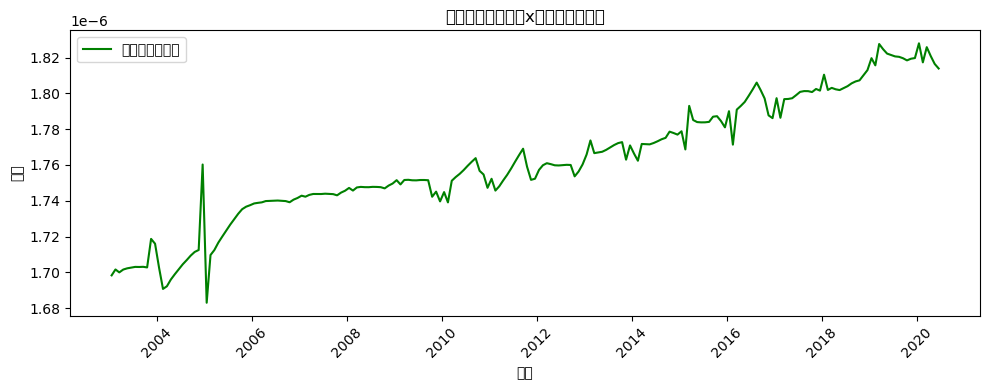

In [736]:
#最后采用分段线性插值后STLdeseasonalized作为deseasonalized methane levels [15°S, 150°W] from 2003-01 to 2020-06 time series
#2004-2020年，全球甲烷浓度在小范围波动中呈稳定的上升趋势。浓度从2004年的1.70ppb左右上升到了2020年的高于1.82ppb，年平均上升率大于0.0075ppb。
#由第2题好像也可以用滑动平均，但我懒得试了

# 关键：给趋势、季节性成分添加时间坐标（转为DataArray）
trend = xr.DataArray(  # 趋势成分带时间轴
    result.trend.astype(np.float32),
    coords={'time': filled.time.values},  # 和插值数据共用同一时间坐标
    dims=['time'],
    name='trend'
)
# 7. 可视化趋势（x轴为时间序列）
plt.figure(figsize=(10, 4))
# 趋势图：x轴直接用 trend.time.values（时间序列）
plt.plot(trend.time.values, trend.values, label='趋势成分', color='orange', linewidth=2)
plt.xlabel('时间')
plt.ylabel('趋势值')
plt.legend()
plt.title('趋势成分（x轴为时间序列）')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

seasonal = xr.DataArray(
    result.seasonal.astype(np.float32),
    coords={'time': filled.time.values},
    dims=['time'],
    name='seasonal'
)
deseasonalized = filled - seasonal

# 8. 完整可视化（插值后+趋势+去季节性）
plt.figure(figsize=(10, 4))
plt.plot(deseasonalized.time.values, deseasonalized.values, label='去季节性后数据', color='green')
plt.xlabel('时间')
plt.ylabel('浓度')
plt.legend()
plt.title('去季节性后数据（x轴为时间序列）')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [737]:
#2.1

# Load the netCDF4 file
sst = xr.open_dataset("NOAA_NCDC_ERSST_v3b_SST.nc", engine="netcdf4")
# Check the datasst
sst

<xarray.Dataset> Size: 44MB
Dimensions:  (lat: 89, lon: 180, time: 684)
Coordinates:
  * lat      (lat) float32 356B -88.0 -86.0 -84.0 -82.0 ... 82.0 84.0 86.0 88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 5kB 1960-01-15 1960-02-15 ... 2016-12-15
Data variables:
    sst      (time, lat, lon) float32 44MB ...
Attributes:
    Conventions:  IRIDL
    source:       https://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCDC/.ERSST/...
    history:      extracted and cleaned by Ryan Abernathey for Research Compu...

In [738]:
#read the SST variable
sst.sst

<xarray.DataArray 'sst' (time: 684, lat: 89, lon: 180)> Size: 44MB
[10957680 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 356B -88.0 -86.0 -84.0 -82.0 ... 82.0 84.0 86.0 88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 5kB 1960-01-15 1960-02-15 ... 2016-12-15
Attributes:
    pointwidth:          1.0
    valid_min:           -3.0
    valid_max:           45.0
    units:               degree_Celsius
    long_name:           Extended reconstructed sea surface temperature
    standard_name:       sea_surface_temperature
    iridl:hasSemantics:  iridl:SeaSurfaceTemperature

In [739]:
sst.sst.time.head()

<xarray.DataArray 'time' (time: 5)> Size: 40B
array(['1960-01-15T00:00:00.000000000', '1960-02-15T00:00:00.000000000',
       '1960-03-15T00:00:00.000000000', '1960-04-15T00:00:00.000000000',
       '1960-05-15T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 40B 1960-01-15 1960-02-15 ... 1960-05-15

In [740]:
#check if there is missing value
sst.sst.max(dim=['lat','lon'])

<xarray.DataArray 'sst' (time: 684)> Size: 3kB
array([30.969938, 30.703114, 30.444391, 30.181942, 30.4165  , 31.455328,
       32.252476, 33.331417, 32.780632, 31.459492, 30.481129, 30.50565 ,
       30.63398 , 30.297714, 30.215845, 30.249687, 30.511915, 31.844105,
       31.93641 , 32.894352, 31.93683 , 31.408968, 30.011497, 30.540413,
       30.822826, 30.084732, 29.842962, 30.082026, 30.411535, 31.789452,
       32.662   , 33.810265, 33.176   , 31.361814, 30.124256, 30.1811  ,
       30.594374, 30.135063, 30.465136, 30.082207, 30.272432, 31.440773,
       32.37563 , 33.10676 , 32.87991 , 31.465654, 30.026268, 30.092585,
       30.124533, 30.13188 , 29.892036, 30.424881, 30.249247, 31.602987,
       32.145283, 33.226555, 32.44055 , 31.539053, 29.901024, 30.246382,
       30.006388, 30.255444, 29.66333 , 29.779753, 29.863194, 31.462791,
       32.392433, 33.12576 , 32.489357, 30.990961, 29.74675 , 29.680193,
       29.616634, 29.616577, 30.18995 , 30.630001, 30.252708, 31.562794,
       31.894217, 32.999817, 32.27283 , 31.107906, 30.015694, 30.107248,
       30.601177, 29.736008, 29.402916, 30.297194, 30.09408 , 31.308582,
       31.651966, 32.261635, 32.209457, 31.583233, 29.760542, 30.248016,
       29.93782 , 29.60284 , 29.67286 , 30.123598, 30.164545, 30.895212,
       32.265045, 32.243145, 32.612984, 31.538866, 30.235323, 30.606506,
       30.20875 , 29.967575, 30.288929, 30.677107, 31.370121, 31.457212,
       32.183613, 32.25438 , 32.439228, 31.091309, 30.062426, 30.573767,
...
       32.163094, 33.1275  , 32.90026 , 31.23765 , 30.202732, 30.586584,
       30.052597, 29.966715, 30.097305, 30.1115  , 30.30835 , 31.656746,
       32.285732, 33.556778, 33.382183, 31.606012, 30.363083, 30.730804,
       30.67452 , 29.966825, 30.279623, 30.711878, 30.471685, 31.588425,
       32.700283, 32.864143, 32.878086, 31.744614, 30.632627, 30.79451 ,
       30.721622, 30.753187, 30.809534, 31.09387 , 31.64547 , 31.646645,
       32.489475, 33.90111 , 33.00326 , 32.39399 , 31.06449 , 30.79662 ,
       30.173668, 29.96962 , 30.126324, 30.492891, 30.470316, 31.385088,
       32.27213 , 32.798397, 32.540394, 31.54164 , 30.206163, 30.635881,
       30.118385, 29.851433, 29.815514, 30.245333, 30.325327, 31.69022 ,
       32.75992 , 33.144207, 33.017944, 32.079853, 30.766047, 31.29078 ,
       30.499622, 30.79581 , 30.095118, 30.523787, 31.160788, 31.463928,
       32.258076, 32.953007, 32.947495, 31.734148, 30.419788, 30.581543,
       30.370243, 30.18057 , 30.232315, 30.4522  , 31.104013, 31.664444,
       32.55938 , 33.45534 , 33.552067, 31.796896, 30.497702, 30.668888,
       30.625496, 30.43969 , 30.45277 , 30.742361, 30.861462, 31.490963,
       32.468056, 33.31517 , 33.4293  , 32.374504, 30.630907, 30.829252,
       30.538746, 30.88209 , 31.048431, 31.072947, 31.16697 , 32.007534,
       32.975445, 33.404354, 33.49701 , 31.858772, 30.979834, 30.798607],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1960-01-15 1960-02-15 ... 2016-12-15

In [741]:
sst.sst.min(dim=['lat','lon'])

<xarray.DataArray 'sst' (time: 684)> Size: 3kB
array([-1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
...
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8, -1.8,
       -1.8, -1.8], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1960-01-15 1960-02-15 ... 2016-12-15

In [742]:
sst.sst.mean(dim=['lat','lon'])
#no missing value

<xarray.DataArray 'sst' (time: 684)> Size: 3kB
array([13.521811 , 13.619477 , 13.643326 , 13.525283 , 13.51987  ,
       13.587143 , 13.810867 , 13.956791 , 13.879199 , 13.605475 ,
       13.413223 , 13.435615 , 13.578588 , 13.725303 , 13.720038 ,
       13.630114 , 13.598686 , 13.662363 , 13.831356 , 14.000452 ,
       13.835338 , 13.589826 , 13.4036665, 13.422518 , 13.570895 ,
       13.68564  , 13.6764   , 13.602735 , 13.557809 , 13.628326 ,
       13.873271 , 14.000162 , 13.895175 , 13.5983715, 13.42531  ,
       13.428566 , 13.550746 , 13.668453 , 13.657319 , 13.593035 ,
       13.577403 , 13.630626 , 13.854904 , 14.021025 , 13.875001 ,
       13.591734 , 13.455551 , 13.467737 , 13.559685 , 13.644446 ,
       13.618786 , 13.502636 , 13.467018 , 13.540408 , 13.6856785,
       13.801994 , 13.705286 , 13.445355 , 13.257425 , 13.275797 ,
       13.478549 , 13.589662 , 13.580085 , 13.49107  , 13.443948 ,
       13.514328 , 13.6987   , 13.894072 , 13.799676 , 13.517533 ,
       13.363269 , 13.402169 , 13.5513315, 13.637283 , 13.642896 ,
       13.542244 , 13.472825 , 13.547495 , 13.759614 , 13.920046 ,
       13.818387 , 13.55919  , 13.419565 , 13.442019 , 13.541349 ,
       13.653423 , 13.666443 , 13.585735 , 13.561741 , 13.613359 ,
       13.801884 , 13.96819  , 13.801436 , 13.542804 , 13.336418 ,
       13.3647995, 13.4766   , 13.598865 , 13.602067 , 13.53516  ,
...
       13.893043 , 13.667948 , 13.693841 , 13.812714 , 13.905424 ,
       13.922463 , 13.8753   , 13.870173 , 13.990845 , 14.206032 ,
       14.352214 , 14.18607  , 13.925509 , 13.760187 , 13.813895 ,
       13.943314 , 14.051433 , 14.037245 , 13.95869  , 13.910834 ,
       13.96565  , 14.1796875, 14.3271265, 14.1891775, 13.87591  ,
       13.674349 , 13.686791 , 13.810424 , 13.928358 , 13.914124 ,
       13.84595  , 13.824758 , 13.917407 , 14.121792 , 14.279964 ,
       14.146663 , 13.861246 , 13.6708765, 13.636401 , 13.777289 ,
       13.914645 , 13.884937 , 13.82372  , 13.831939 , 13.919031 ,
       14.185805 , 14.354998 , 14.275267 , 13.968827 , 13.749528 ,
       13.758018 , 13.85081  , 13.963951 , 13.938723 , 13.886424 ,
       13.871103 , 13.930299 , 14.205839 , 14.374609 , 14.221628 ,
       13.929042 , 13.7803   , 13.749846 , 13.862934 , 13.9729595,
       13.989931 , 13.946334 , 13.931303 , 14.042193 , 14.262478 ,
       14.460216 , 14.353545 , 14.024182 , 13.808441 , 13.806778 ,
       13.9483   , 14.042367 , 14.059336 , 14.015626 , 14.0065155,
       14.081276 , 14.298853 , 14.47104  , 14.384661 , 14.139942 ,
       13.933816 , 13.950227 , 14.097406 , 14.157721 , 14.160664 ,
       14.072133 , 14.014931 , 14.106248 , 14.323242 , 14.469313 ,
       14.359503 , 14.070898 , 13.851527 , 13.848249 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1960-01-15 1960-02-15 ... 2016-12-15

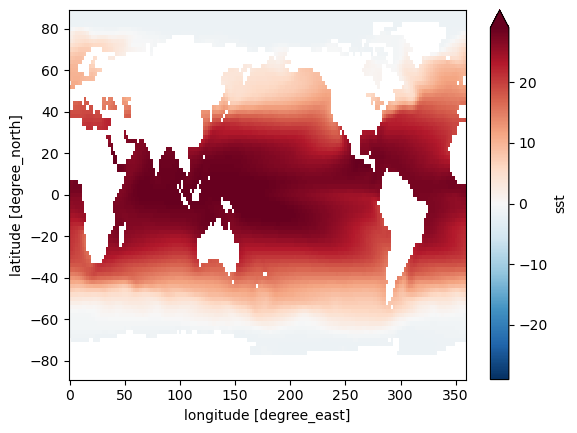

In [743]:
#plot mean SST
sst.sst.mean(dim='time').plot(robust=True)
plt.show()
#赤道高，两极低，陆地覆盖的地方无数据

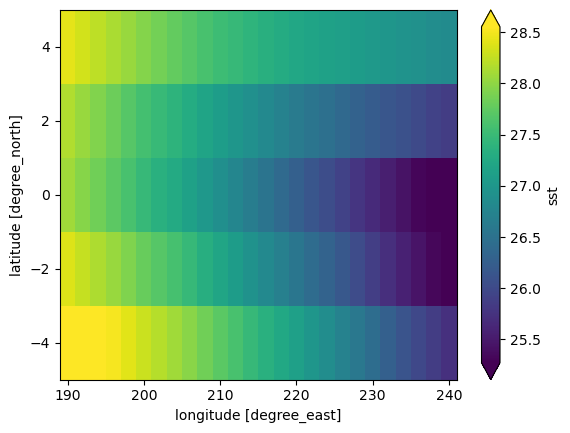

In [744]:
#target Niño 3.4 places
sst1 = sst.sst.sel(lon=slice(190,240), lat=slice(-5,5))
sst1.mean(dim='time').plot(robust=True)
plt.show()

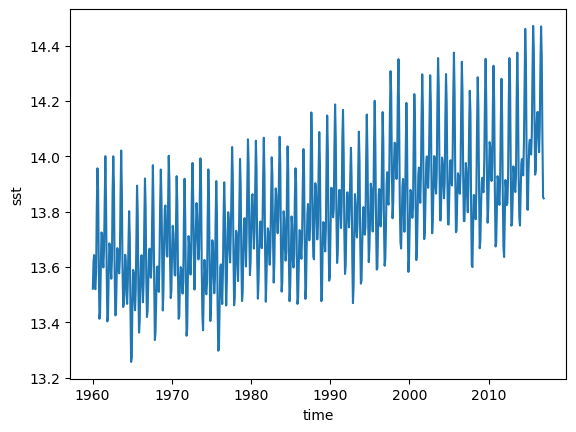

In [745]:
#plot global monthly SST time series
sst2 = sst.sst.mean(dim=['lat','lon'])
sst2.plot()
plt.show()
#总体呈缓慢而稳定的上升趋势，有极频繁的季节性剧烈波动,这个波动大多数情况下显得很整齐，在部分数据例如1960-1980平均值下半部分的部分月份数据比较杂乱，上升趋势内部有波动

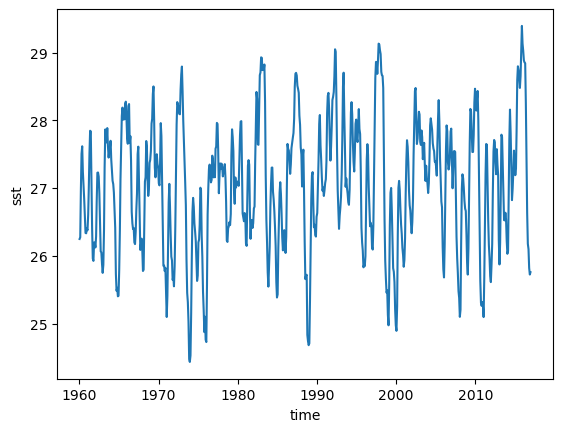

<xarray.DataArray 'sst' (time: 684)> Size: 3kB
array([26.248539, 26.274082, 26.971754, 27.507061, 27.617926, 27.240377,
       27.057302, 26.83924 , 26.585983, 26.33765 , 26.332773, 26.404753,
       26.376646, 26.60832 , 26.99953 , 27.508902, 27.847439, 27.837452,
       27.128933, 26.405888, 25.959885, 25.92513 , 26.197374, 26.196138,
       26.123337, 26.286663, 26.803873, 27.2271  , 27.230991, 27.171183,
       26.922546, 26.50737 , 26.06504 , 26.051397, 25.87596 , 25.747963,
       25.866718, 26.385565, 27.309532, 27.867428, 27.704853, 27.674984,
       27.886913, 27.619843, 27.45118 , 27.551765, 27.602205, 27.699335,
       27.419674, 27.266   , 27.109365, 27.059664, 26.93354 , 26.652122,
       26.415096, 25.730236, 25.483685, 25.52768 , 25.401709, 25.408653,
       25.78512 , 26.373917, 27.127306, 27.617397, 28.063898, 28.189219,
       28.011286, 28.06265 , 28.015797, 28.241869, 28.27687 , 28.05463 ,
       27.74407 , 27.655352, 28.213928, 28.24211 , 27.668356, 27.766865,
       27.407253, 26.649035, 26.477654, 26.396759, 26.411129, 26.198921,
       26.172836, 26.355581, 26.673729, 26.920546, 27.502365, 27.612421,
       27.15856 , 26.612715, 26.087511, 26.17572 , 26.253477, 26.09462 ,
       25.77567 , 25.794838, 26.38668 , 27.09576 , 27.161087, 27.695478,
       27.603516, 27.10938 , 26.884932, 26.979708, 27.372839, 27.415842,
       27.549463, 27.953718, 28.024025, 28.391148, 28.50205 , 27.995497,
       27.301783, 27.159801, 27.334291, 27.500496, 27.354988, 27.307852,
...
       26.929962, 26.28247 , 25.960001, 25.746786, 25.476297, 25.379417,
       25.098265, 25.203148, 26.172518, 26.983387, 27.203423, 27.146795,
       27.004684, 26.810644, 26.69641 , 26.663078, 26.321892, 25.892977,
       25.722786, 26.113506, 26.809345, 27.663242, 28.169899, 28.131285,
       27.81389 , 27.532824, 27.534788, 27.78205 , 28.264318, 28.46822 ,
       28.244532, 28.145636, 28.321102, 28.435   , 28.016808, 27.222816,
       26.382465, 25.629625, 25.308199, 25.26089 , 25.317698, 25.262629,
       25.094921, 25.685167, 26.383703, 27.207521, 27.652033, 27.64105 ,
       27.086914, 26.523228, 26.157032, 25.97101 , 25.69644 , 25.611502,
       25.866926, 26.17625 , 26.93843 , 27.541918, 27.710892, 27.67402 ,
       27.371653, 27.205072, 27.574745, 27.345116, 27.191526, 26.230288,
       25.872486, 26.193375, 26.87241 , 27.789312, 27.756186, 27.363054,
       26.932598, 26.527586, 26.523426, 26.635916, 26.535381, 26.221733,
       26.030083, 26.07117 , 26.85875 , 27.71646 , 28.159866, 27.806387,
       27.287312, 26.822744, 26.993048, 27.236206, 27.553871, 27.337038,
       27.191298, 27.286846, 27.833305, 28.598623, 28.799318, 28.740726,
       28.603338, 28.480112, 28.652964, 29.04132 , 29.39597 , 29.135164,
       29.029905, 28.885473, 28.857891, 28.845009, 28.259611, 27.48583 ,
       26.631878, 26.176836, 26.098179, 25.820839, 25.722893, 25.75819 ],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1960-01-15 1960-02-15 ... 2016-12-15

In [746]:
#plot monthly SST time series at the Niño 3.4 places
SST = sst.sst.sel(lon=slice(190,240), lat=slice(-5,5)).mean(dim=['lat','lon'])
SST.plot()
plt.show()
SST
#剧烈的波动，上下可达到约5度，海温高，波动频率有季节性，看起来很混乱

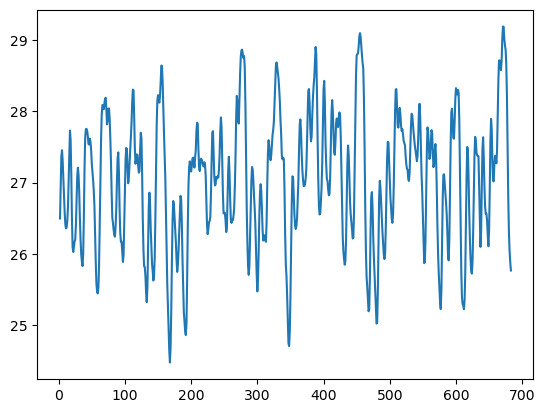

In [747]:
#计算3个月的滚动平均值
#本来用下面这个方法，但是算出来的值是每个月在变化的，波动太大了，导致后续根本没有满足连续5个月条件的时间段
#source: https://geek-blogs.com/blog/rolling-average-python/#:~:text=%E5%9C%A8%20Python%20%E4%B8%AD%EF%BC%8C%E6%88%91%E4%BB%AC%E5%8F%AF%E4%BB%A5%E4%BD%BF%E7%94%A8%20pandas%20%E5%BA%93%E6%9D%A5%E8%AE%A1%E7%AE%97%E6%BB%9A%E5%8A%A8%E5%B9%B3%E5%9D%87%E5%80%BC%E3%80%82%20pandas%20%E6%8F%90%E4%BE%9B%E4%BA%86,rolling%28%29%20%E6%96%B9%E6%B3%95%EF%BC%8C%E8%AF%A5%E6%96%B9%E6%B3%95%E5%8F%AF%E4%BB%A5%E6%96%B9%E4%BE%BF%E5%9C%B0%E5%9C%A8%20Series%20%E6%88%96%20DataFrame%20%E5%AF%B9%E8%B1%A1%E4%B8%8A%E8%AE%A1%E7%AE%97%E6%BB%9A%E5%8A%A8%E7%BB%9F%E8%AE%A1%E9%87%8F%E3%80%82%20%E4%BB%A5%E4%B8%8B%E6%98%AF%E4%B8%80%E4%B8%AA%E7%AE%80%E5%8D%95%E7%9A%84%E4%BB%A3%E7%A0%81%E7%A4%BA%E4%BE%8B%EF%BC%9A
#https://geek-docs.com/numpy/numpy-ask-answer/47_hk_1708827325.html

series = pd.Series(SST)
rolling_avg = series.rolling(window=3).mean() #窗口大小为3
rolling_avg.plot()
plt.show()

In [748]:
#计算3个月的滚动平均值 source: 豆包

#用多次分组，groupby多个条件的方式计算每年1-3月，4-6月，7-9月，10-12月的滑动平均值
#先给全部1-3月，4-6月，7-9月，10-12月赋值 
SST['Y'] = SST.time.dt.year

#这里使用ABCD排序，避免后续因为首字母导顺序混乱
SST['M'] = SST.time.dt.month
SST.M
SST['S'] = 'A'
SST['S'] = SST['S'].where(~ ((SST['M'] <= 6 ) & (SST['M'] > 3 )), 'B')
SST['S'] = SST['S'].where(~ ((SST['M'] <= 9 ) & (SST['M'] > 6 )), 'C')
SST['S'] = SST['S'].where(~ ((SST['M'] <= 12 ) & (SST['M'] > 9 )), 'D')
SST.S

# Group by the season then by year
SST = SST.sortby('time')
SST2 = SST.groupby(['Y', 'S']).mean(dim='time')  # 每年每季度的平均值
# 步骤1：重置 S 维度的坐标为自然季节顺序
SST2 = SST2.reindex(S=['A','B','C','D'])
# 步骤2：按年份+季节排序（此时排序会生效）
SST2 = SST2.sortby(['Y', 'S'])
SST2

<xarray.DataArray 'sst' (Y: 57, S: 4)> Size: 2kB
array([[26.49812508, 27.45512199, 26.82750893, 26.35839272],
       [26.66149902, 27.73126221, 26.4982357 , 26.10621452],
       [26.40462494, 27.20975685, 26.49831963, 25.89177513],
       [26.52060509, 27.74909019, 27.6526432 , 27.61776733],
       [27.26501465, 26.8817749 , 25.87633705, 25.4460144 ],
       [26.4287796 , 27.95683861, 28.02991295, 28.19112206],
       [27.87111664, 27.8924427 , 26.84464836, 26.33560181],
       [26.40071678, 27.34510994, 26.61959648, 26.17460632],
       [25.98572731, 27.31744194, 27.19927788, 27.25612831],
       [27.8424015 , 28.29623222, 27.26529121, 27.38777924],
       [27.15987396, 27.62168884, 26.06180382, 25.68870544],
       [25.53784943, 26.85921288, 26.07868195, 25.62748146],
       [26.50122261, 28.14735413, 28.12203407, 28.64276123],
       [28.04799461, 27.0757618 , 25.56976128, 24.64379883],
       [25.20170784, 26.74214745, 26.35252571, 25.74825096],
       [26.30028725, 26.76011658, 25.55169106, 24.91102791],
       [25.64135742, 27.21199608, 27.1560421 , 27.35161781],
       [27.3525486 , 27.84190941, 27.22532654, 27.33599281],
       [27.24549294, 27.2567749 , 26.40844536, 26.44499779],
       [26.85094261, 27.72265053, 26.96067238, 27.05735016],
...
       [26.5688324 , 28.49118042, 28.81181908, 29.09786987],
       [28.78838539, 28.18482399, 26.03874397, 25.35656738],
       [25.6702652 , 26.86816216, 25.95493889, 25.26384163],
       [25.47827339, 27.02692413, 26.49367714, 25.98878479],
       [26.37004662, 27.57266045, 27.02684975, 26.49269867],
       [26.94457054, 28.30576134, 27.80342293, 28.04885674],
       [27.72483253, 27.58451843, 27.36888695, 27.18094635],
       [27.13972282, 27.96625328, 27.70395851, 27.44651222],
       [27.38252258, 28.10684013, 27.12322426, 26.21653748],
       [26.22562218, 27.77469063, 27.33289528, 27.73634911],
       [27.21758461, 27.54202843, 26.39081001, 25.53416634],
       [25.49131012, 27.11120033, 26.83724785, 26.29264832],
       [26.21521187, 27.98814201, 27.62716675, 28.17152977],
       [28.23709106, 27.89154053, 25.77342987, 25.28040504],
       [25.72126579, 27.50020027, 26.58905792, 25.75965118],
       [26.32720184, 27.64227486, 27.3838253 , 26.92230988],
       [26.31275749, 27.63618469, 26.66120338, 26.46434212],
       [26.3200016 , 27.89423943, 27.03436852, 27.37570381],
       [27.43714905, 28.71289062, 28.57880402, 29.19081879],
       [28.92442322, 28.1968174 , 26.30229759, 25.76730919]])
Coordinates:
  * Y        (Y) int64 456B 1960 1961 1962 1963 1964 ... 2013 2014 2015 2016
  * S        (S) object 32B 'A' 'B' 'C' 'D'

In [749]:
# 广播回原始时间维度（核心！将季度均值赋值给对应季度的每个月份，保留684个点） 
SST3 = SST.groupby(['Y', 'M']).map(lambda x: SST2.sel(Y=x.Y[0], S=x.S[0]))
SST3

<xarray.DataArray 'sst' (Y: 57, M: 12)> Size: 5kB
array([[26.49812508, 26.49812508, 26.49812508, 27.45512199, 27.45512199,
        27.45512199, 26.82750893, 26.82750893, 26.82750893, 26.35839272,
        26.35839272, 26.35839272],
       [26.66149902, 26.66149902, 26.66149902, 27.73126221, 27.73126221,
        27.73126221, 26.4982357 , 26.4982357 , 26.4982357 , 26.10621452,
        26.10621452, 26.10621452],
       [26.40462494, 26.40462494, 26.40462494, 27.20975685, 27.20975685,
        27.20975685, 26.49831963, 26.49831963, 26.49831963, 25.89177513,
        25.89177513, 25.89177513],
       [26.52060509, 26.52060509, 26.52060509, 27.74909019, 27.74909019,
        27.74909019, 27.6526432 , 27.6526432 , 27.6526432 , 27.61776733,
        27.61776733, 27.61776733],
       [27.26501465, 27.26501465, 27.26501465, 26.8817749 , 26.8817749 ,
        26.8817749 , 25.87633705, 25.87633705, 25.87633705, 25.4460144 ,
        25.4460144 , 25.4460144 ],
       [26.4287796 , 26.4287796 , 26.4287796 , 27.95683861, 27.95683861,
        27.95683861, 28.02991295, 28.02991295, 28.02991295, 28.19112206,
        28.19112206, 28.19112206],
       [27.87111664, 27.87111664, 27.87111664, 27.8924427 , 27.8924427 ,
        27.8924427 , 26.84464836, 26.84464836, 26.84464836, 26.33560181,
...
        27.89154053, 25.77342987, 25.77342987, 25.77342987, 25.28040504,
        25.28040504, 25.28040504],
       [25.72126579, 25.72126579, 25.72126579, 27.50020027, 27.50020027,
        27.50020027, 26.58905792, 26.58905792, 26.58905792, 25.75965118,
        25.75965118, 25.75965118],
       [26.32720184, 26.32720184, 26.32720184, 27.64227486, 27.64227486,
        27.64227486, 27.3838253 , 27.3838253 , 27.3838253 , 26.92230988,
        26.92230988, 26.92230988],
       [26.31275749, 26.31275749, 26.31275749, 27.63618469, 27.63618469,
        27.63618469, 26.66120338, 26.66120338, 26.66120338, 26.46434212,
        26.46434212, 26.46434212],
       [26.3200016 , 26.3200016 , 26.3200016 , 27.89423943, 27.89423943,
        27.89423943, 27.03436852, 27.03436852, 27.03436852, 27.37570381,
        27.37570381, 27.37570381],
       [27.43714905, 27.43714905, 27.43714905, 28.71289062, 28.71289062,
        28.71289062, 28.57880402, 28.57880402, 28.57880402, 29.19081879,
        29.19081879, 29.19081879],
       [28.92442322, 28.92442322, 28.92442322, 28.1968174 , 28.1968174 ,
        28.1968174 , 26.30229759, 26.30229759, 26.30229759, 25.76730919,
        25.76730919, 25.76730919]])
Coordinates:
  * Y        (Y) int64 456B 1960 1961 1962 1963 1964 ... 2013 2014 2015 2016
  * M        (M) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    S        (Y, M) <U1 3kB 'A' 'A' 'A' 'B' 'B' 'B' ... 'C' 'C' 'C' 'D' 'D' 'D'
    time     (Y, M) datetime64[ns] 5kB 1960-01-15 1960-02-15 ... 2016-12-15

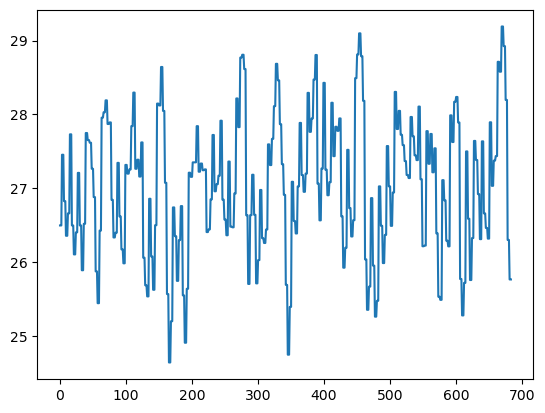

In [768]:
#展平为一维纯数值，去掉Y/S分组标签，长度为684
SST3_flat = SST3.values.flatten()
SST3_flat

#得到滑动平均值图
plt.plot(SST3_flat)
plt.show()

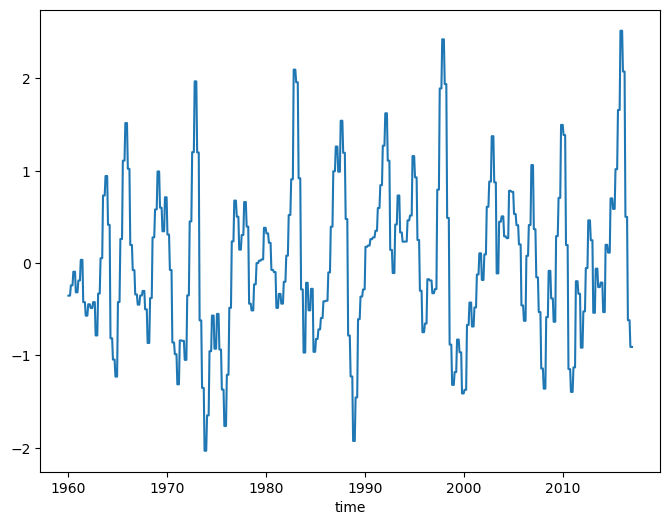

In [805]:
#不是很懂这个subtract climatology from SST time series to obtain anomalies是什么意思，去问了AI
#气候态：某一长期时期（如 1981-2010 年）内，每个月份的平均海温（比如所有 1 月的平均、所有 2 月的平均，而非整段时期的总平均）
# 给SST3_flat添加时间坐标（和SST的time维度一致）
SST4 = xr.DataArray(
    SST3_flat,
    coords={'time': SST.time},
    dims=['time']
)
SST4
# 2. 按月份计算气候态（比如所有1月的滚动平均均值、所有2月的均值...）
climatology = SST4.groupby('time.month').mean(dim='time')
climatology

# 3. 计算标准异常值（滚动平均 - 气候态，去掉季节循环）
SST4['month'] = SST.time.dt.month
sst_anom = SST4.groupby('time.month').map(lambda x: x - climatology.sel(month=x.month[0]))
sst_anom.plot(size=6)
plt.show()
#比上面得到的平滑很多

<Figure size 1200x600 with 0 Axes>

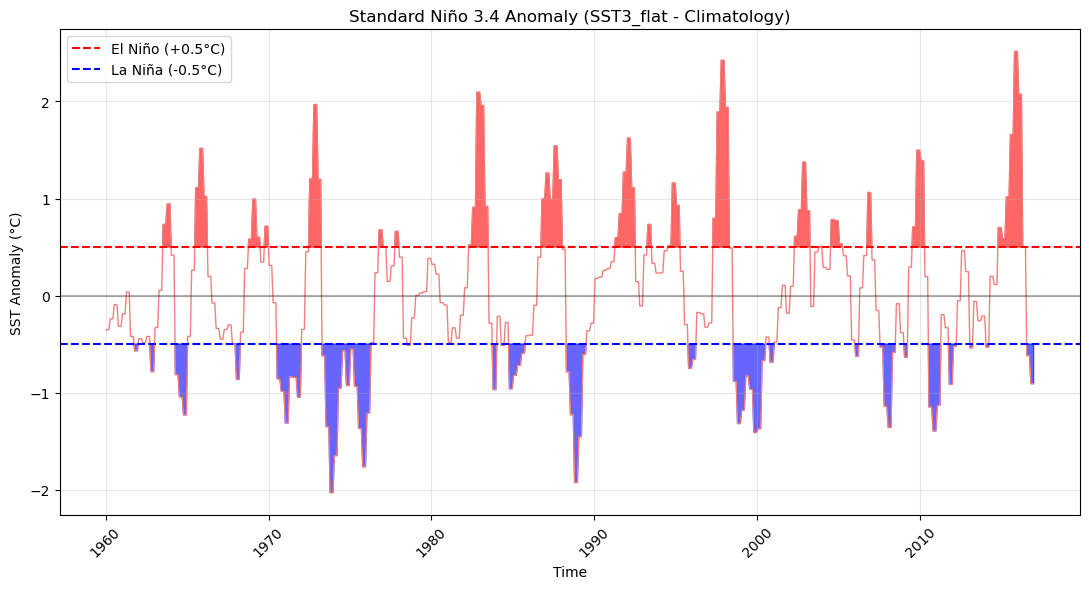

厄尔尼诺事件次数：20
拉尼娜事件次数：22


In [817]:
#2.2

#source: 豆包
fig, ax = plt.subplots(figsize=(11,6))

# ---------------------- 根据阈值填色 ----------------------
# 1. 厄尔尼诺区域（异常值 ≥ 0.5°C，填充红色）
#   where条件：只填充y在阈值以上的区域，下方用0截断（与基线之间填色）
# 1. 厄尔尼诺区域（≥0.5°C，红色填充）
ax.fill_between(
    sst_anom.time,  # x轴：时间（和你原有曲线一致）
    sst_anom.values,  # y轴：异常值
    0.5,  # 填充下限：厄尔尼诺阈值
    where=(sst_anom.values >= 0.5),  # 仅填充超过阈值的区域
    interpolate=True,  # 平滑边界
    color='red', alpha=0.6  # 颜色+透明度（不遮挡原有曲线）
)

# 2. 拉尼娜区域（≤-0.5°C，蓝色填充）
ax.fill_between(
    sst_anom.time,
    sst_anom.values,
    -0.5,  # 填充上限：拉尼娜阈值
    where=(sst_anom.values <= -0.5),
    interpolate=True,
    color='blue', alpha=0.6
)

# 标准异常值（平滑，可识别事件）
ax.plot(sst_anom.time, sst_anom.values, color='lightcoral', linewidth=1)
ax.axhline(y=0.5, color='red', linestyle='--', label='El Niño (+0.5°C)')
ax.axhline(y=-0.5, color='blue', linestyle='--', label='La Niña (-0.5°C)')
ax.axhline(y=0, color='black', alpha=0.3)
ax.set_title('Standard Niño 3.4 Anomaly (SST3_flat - Climatology)', fontsize=12)
ax.set_ylabel('SST Anomaly (°C)')
ax.set_xlabel('Time')
ax.legend()
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# 假设 sst_anom 已计算（3个月滚动平均后的异常值，含time维度）
# 确保数据无NaN（若有缺失需提前处理）
sst_anom_clean = sst_anom.dropna(dim='time')
anom_vals = sst_anom_clean.values  # 异常值数组
anom_times = sst_anom_clean.time.values  # 时间数组

# 定义阈值（与NOAA标准一致）
el_nino_threshold = 0.5    # 厄尔尼诺阈值
la_nina_threshold = -0.5   # 拉尼娜阈值

# 创建图形（设置合适的大小和分辨率）
plt.figure(figsize=(12, 6), dpi=100)

# 识别连续5个月±0.5°C的事件
sst_anom_clean = sst_anom.dropna(dim='time')
vals = sst_anom_clean.values
times = sst_anom_clean.time.values

# 厄尔尼诺（连续≥5个月≥0.5°C）
el_nino = np.convolve(vals >= 0.5, np.ones(5), 'same') >= 5
# 拉尼娜（连续≥5个月≤-0.5°C）
la_nina = np.convolve(vals <= -0.5, np.ones(5), 'same') >= 5

print(f"厄尔尼诺事件次数：{len(times[el_nino])//5}")
print(f"拉尼娜事件次数：{len(times[la_nina])//5}")
#观察到厄尔尼诺和拉尼娜现象（或者说海温异常值）在年际范围上交替上下波动，峰值可达到+-两度，一般两次厄尔尼诺现象间隔不超过5年，拉尼娜在大波动间的间隔可以达到近10年。
#自1980年以来，厄尔尼诺现象频率有一点提升，较拉尼娜现象更多，幅度更大

<Figure size 1200x600 with 0 Axes>

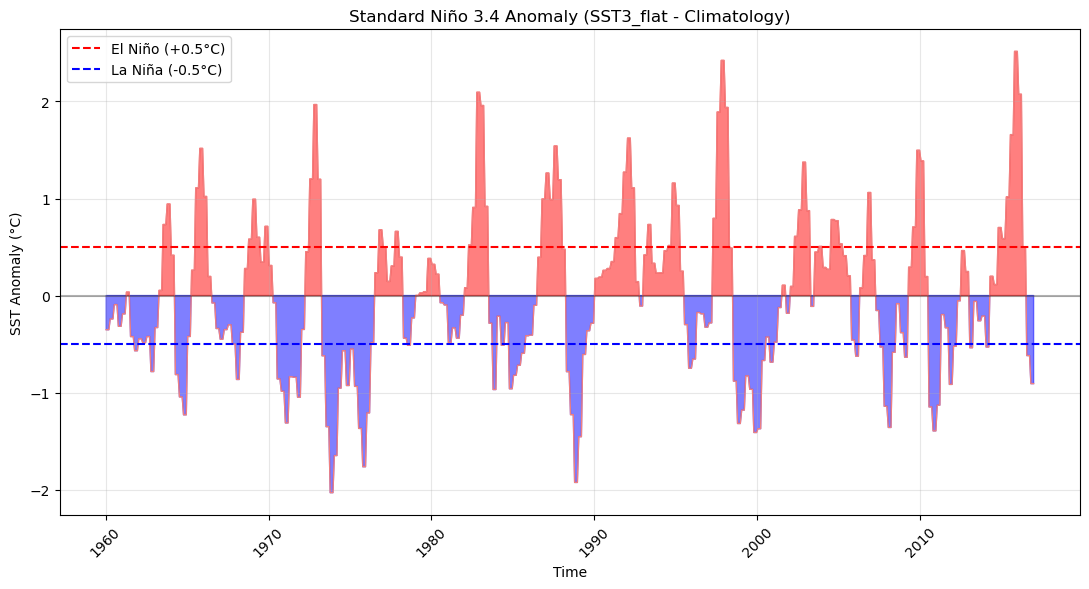

<Figure size 1200x600 with 0 Axes>

In [816]:
#全部填色风格
fig, ax = plt.subplots(figsize=(11,6))

# ---------------------- 根据阈值填色 ----------------------
# 1. 异常值>0的区域（全部填红色，不管是否≥0.5°C）
ax.fill_between(
    sst_anom.time,  # x轴：时间
    sst_anom.values,  # y轴：异常值
    0,  # 填充下限：0轴（基线）
    where=(sst_anom.values > 0),# 去掉 where 条件，所有>0的区域都填色
    interpolate=True,  # 平滑边界
    color='red', alpha=0.5  
)

# 2. 异常值<0的区域（全部填蓝色，不管是否≤-0.5°C）
ax.fill_between(
    sst_anom.time,
    sst_anom.values,
    0,  # 填充上限：0轴（基线）
    where=(sst_anom.values < 0),# 去掉 where 条件，所有<0的区域都填色
    interpolate=True,
    color='blue', alpha=0.5
)

# 标准异常值（平滑，可识别事件）
ax.plot(sst_anom.time, sst_anom.values, color='lightcoral', linewidth=1)
ax.axhline(y=0.5, color='red', linestyle='--', label='El Niño (+0.5°C)')
ax.axhline(y=-0.5, color='blue', linestyle='--', label='La Niña (-0.5°C)')
ax.axhline(y=0, color='black', alpha=0.3)
ax.set_title('Standard Niño 3.4 Anomaly (SST3_flat - Climatology)', fontsize=12)
ax.set_ylabel('SST Anomaly (°C)')
ax.set_xlabel('Time')
ax.legend()
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# 假设 sst_anom 已计算（3个月滚动平均后的异常值，含time维度）
# 确保数据无NaN（若有缺失需提前处理）
sst_anom_clean = sst_anom.dropna(dim='time')
anom_vals = sst_anom_clean.values  # 异常值数组
anom_times = sst_anom_clean.time.values  # 时间数组

# 定义阈值（与NOAA标准一致）
el_nino_threshold = 0.5    # 厄尔尼诺阈值
la_nina_threshold = -0.5   # 拉尼娜阈值

# 创建图形（设置合适的大小和分辨率）
plt.figure(figsize=(12, 6), dpi=100)

In [3]:
#3.1

# reference: Huffman, G.J., A. Behrangi, D.T. Bolvin, E.J. Nelkin (2022), GPCP Version 3.2 Satellite-Gauge (SG) Combined Precipitation Data Set, Edited by Huffman, G.J., A. Behrangi, D.T. Bolvin, E.J. Nelkin, Greenbelt, Maryland, USA, Goddard Earth Sciences Data and Information Services Center (GES DISC), Accessed: [Data Access Date], 10.5067/MEASURES/GPCP/DATA304

# 尝试过用wget批量下载，报错 https://blog.csdn.net/bullety/article/details/131313150#:~:text=%E6%96%87%E7%AB%A0%E4%BB%8B%E7%BB%8D%E4%BA%86%E5%A6%82%E4%BD%95%E5%88%A9%E7%94%A8wget%E5%B7%A5%E5%85%B7%E5%9C%A8Windows%E7%8E%AF%E5%A2%83%E4%B8%8B%E6%89%B9%E9%87%8F%E4%B8%8B%E8%BD%BDEarthdata%E7%9A%84%E6%95%B0%E6%8D%AE%EF%BC%8C%E5%8C%85%E6%8B%AC%E5%B0%86wget.exe%E5%92%8Cdownload.txt%E6%94%BE%E7%BD%AE%E5%9C%A8%E5%90%8C%E4%B8%80%E7%9B%AE%E5%BD%95%EF%BC%8C%E4%BD%BF%E7%94%A8cmd%E5%91%BD%E4%BB%A4%E8%A1%8C%E6%89%A7%E8%A1%8C%E4%B8%8B%E8%BD%BD%E6%93%8D%E4%BD%9C%EF%BC%8C%E4%BB%A5%E5%8F%8A%E4%BF%AE%E6%94%B9%E5%91%BD%E4%BB%A4%E4%B8%AD%E7%9A%84%E7%94%A8%E6%88%B7%E5%90%8D%E5%92%8C%E5%AF%86%E7%A0%81%E3%80%82,%E4%B8%8B%E8%BD%BD%E5%AE%8C%E6%88%90%E5%90%8E%EF%BC%8C%E8%BF%98%E6%8F%90%E4%BE%9B%E4%BA%86%E5%8E%BB%E9%99%A4nc%E6%95%B0%E6%8D%AE%E6%96%87%E4%BB%B6%E5%A4%8D%E6%9D%82%E5%90%8E%E7%BC%80%E7%9A%84%E6%96%B9%E6%B3%95%E3%80%82

# 2022-2023年7月的卫星降水数据

# 来源: https://www.heywhale.com/mw/project/62660972af51920017414a26
%cd C:\Users\YiChen\ps31

%ls *.nc4 #输出nc文件

C:\Users\YiChen\ps31
 驱动器 C 中的卷是 Windows-SSD
 卷的序列号是 2CDC-E465

 C:\Users\YiChen\ps31 的目录


 C:\Users\YiChen\ps31 的目录

2025/11/26  17:15         7,487,139 GPCP_gauge_precip_timeseries_202101-202307.nc4
2025/11/26  16:57         6,772,688 GPCPMON_L3_202101_V3.2.nc4
2025/11/26  16:57         6,772,688 GPCPMON_L3_202102_V3.2.nc4
2025/11/26  16:57         6,772,688 GPCPMON_L3_202103_V3.2.nc4
2025/11/26  16:57         6,772,688 GPCPMON_L3_202104_V3.2.nc4
2025/11/26  16:57         6,772,688 GPCPMON_L3_202105_V3.2.nc4
2025/11/26  16:57         6,772,688 GPCPMON_L3_202106_V3.2.nc4
2025/11/26  16:57         6,772,688 GPCPMON_L3_202107_V3.2.nc4
2025/11/26  16:58         6,772,688 GPCPMON_L3_202108_V3.2.nc4
2025/11/26  16:58         6,772,688 GPCPMON_L3_202109_V3.2.nc4
2025/11/26  16:58         6,772,688 GPCPMON_L3_202110_V3.2.nc4
2025/11/26  16:58         6,772,688 GPCPMON_L3_202111_V3.2.nc4
2025/11/26  16:58         6,772,688 GPCPMON_L3_202112_V3.2.nc4
2025/11/26  15:29         6,772,688 GPCPMO

In [45]:
# Load the netCDF4 file
ds = xr.open_dataset("GPCPMON_L3_202210_V3.2.nc4", engine="netcdf4")
# Check the data
ds

<xarray.Dataset> Size: 8MB
Dimensions:                   (lon: 720, lat: 360, time: 1, bnds: 2)
Coordinates:
  * lon                       (lon) float32 3kB -179.8 -179.2 ... 179.2 179.8
  * lat                       (lat) float32 1kB 89.75 89.25 ... -89.25 -89.75
  * time                      (time) datetime64[ns] 8B 2022-10-01
Dimensions without coordinates: bnds
Data variables:
    sat_gauge_precip          (time, lat, lon) float32 1MB ...
    sat_gauge_error           (time, lat, lon) float32 1MB ...
    satellite_precip          (time, lat, lon) float32 1MB ...
    satellite_source          (time, lat, lon) float32 1MB ...
    gauge_precip              (time, lat, lon) float32 1MB ...
    probability_liquid_phase  (time, lat, lon) float32 1MB ...
    gauge_relative_weight     (time, lat, lon) float32 1MB ...
    quality_index             (time, lat, lon) float32 1MB ...
    time_bnds                 (time, bnds) datetime64[ns] 16B ...
Attributes: (12/66)
    ShortName:                      GPCPMON
    LongName:                       GPCP Precipitation Level 3 Monthly 0.5-De...
    VersionID:                      3.2
    GranuleID:                      GPCPMON_L3_202210_V3.2.nc4
    Format:                         NetCDF-4
    RangeBeginningDate:             2022-10-01
    ...                             ...
    Distribution_Size:              Approximately 7 MB per file
    Distribution_Format:            NetCDF-4
    IdentifierProductDOIAuthority:  http://dx.doi.org/
    Fees:                           None
    ProcessingLevel:                Level 3
    Institution:                    Mesoscale Atmospheric Processes Laborator...

In [5]:
ds.satellite_precip

<xarray.DataArray 'satellite_precip' (time: 1, lat: 360, lon: 720)> Size: 1MB
[259200 values with dtype=float32]
Coordinates:
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * time     (time) datetime64[ns] 8B 2022-10-01
Attributes:
    units:         mm/day
    long_name:     multisatellite precipitation
    valid_range:   [  0. 100.]
    cell_methods:  time: mean

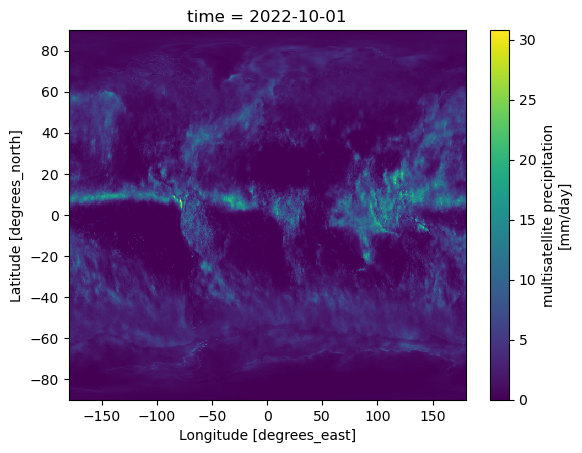

In [6]:
ds.satellite_precip.plot()
plt.show()

In [7]:
#use wind-loss adjusted gauge precipitation
ds.gauge_precip

<xarray.DataArray 'gauge_precip' (time: 1, lat: 360, lon: 720)> Size: 1MB
[259200 values with dtype=float32]
Coordinates:
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * time     (time) datetime64[ns] 8B 2022-10-01
Attributes:
    units:         mm/day
    long_name:     wind-loss adjusted gauge precipitation
    valid_range:   [  0. 100.]
    cell_methods:  time: mean

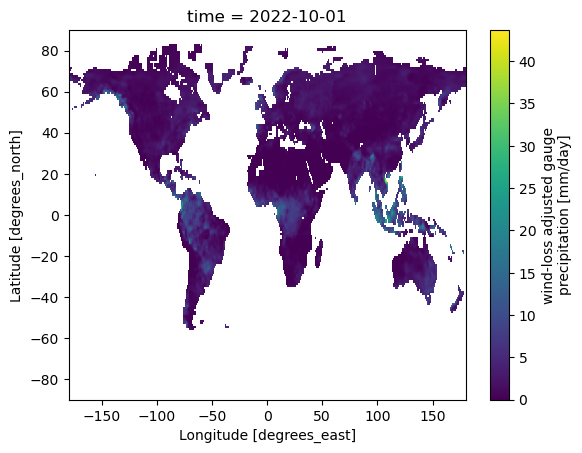

In [8]:
ds.gauge_precip.plot()
plt.show()

In [13]:
# source: 豆包--------------------------------------------------------------------------------

# 1. 读取当前目录下所有GPCP nc4文件
print("正在查找当前目录下的GPCP文件...")
nc_files = [f for f in os.listdir(os.getcwd()) if f.startswith("GPCPMON_L3_") and f.endswith(".nc4")]

if not nc_files:
    raise FileNotFoundError(
        f"在当前目录（{os.getcwd()}）中未找到GPCP文件！\n"
        "请确认：1. 文件格式为 GPCPMON_L3_YYYYMM_V3.2.nc4；2. 文件已放在 C:\\Users\\YiChen 目录下"
    )

# 2. 修复文件名解析：用正则表达式提取6位年月数字（如202101）
def extract_ym(filename):
    """用正则匹配文件名中的6位数字（YYYYMM格式），适配 GPCPMON_L3_202101_V3.2.nc4"""
    match = re.search(r'(\d{6})', filename)  # 匹配6个连续数字
    if match:
        return match.group(1)
    else:
        raise ValueError(f"文件名 {filename} 中未找到6位年月数字（如202201），请检查文件格式！")

# 按年月排序（修复后可正确排序）
nc_files.sort(key=lambda x: extract_ym(x))
nc_file_paths = [f for f in nc_files]
file_yms = [extract_ym(f) for f in nc_files]

# 显示文件信息（现在会正确显示时间范围）
print(f"✅ 找到 {len(nc_files)} 个文件")
print(f"现有文件时间范围：{file_yms[0]} → {file_yms[-1]}")
print(f"文件列表（按时间排序）：{nc_files}")  # 可选：查看排序后的文件列表

# 3. 批量读取并合并文件
ds_list = []
for file_path in nc_file_paths:
    ds = xr.open_dataset(file_path, engine="netcdf4")  # 小写引擎名
    ds_list.append(ds)

# 合并：覆盖元数据冲突，按time维度拼接
ds_combined = xr.concat(
    objs=ds_list,
    dim="time",
    combine_attrs="override"  # 忽略元数据差异
)

# 4. 修正time坐标（确保与文件名一致）
times = pd.to_datetime(file_yms, format="%Y%m")
ds_combined = ds_combined.assign_coords(time=times)

# 5. 变量名校验
var_name = ["gauge_precip", "satellite_precip"]
missing_vars = [var for var in var_name if var not in ds_combined.variables]
if missing_vars:
    print(f"\n❌ 以下变量不存在于文件中：{missing_vars}")
    print(f"文件中可用变量：{list(ds_combined.variables.keys())}")
    # 让用户补充正确的变量名（如果有拼写错误）
    for var in missing_vars:
        new_var = input(f"请输入 '{var}' 对应的正确变量名（复制上面列表中的一个）：")
        var_names[var_name.index(var)] = new_var  # 替换为正确变量名
# 只保留两个目标变量
ds_combined = ds_combined[var_name]

正在查找当前目录下的GPCP文件...
✅ 找到 31 个文件
现有文件时间范围：202101 → 202307
文件列表（按时间排序）：['GPCPMON_L3_202101_V3.2.nc4', 'GPCPMON_L3_202102_V3.2.nc4', 'GPCPMON_L3_202103_V3.2.nc4', 'GPCPMON_L3_202104_V3.2.nc4', 'GPCPMON_L3_202105_V3.2.nc4', 'GPCPMON_L3_202106_V3.2.nc4', 'GPCPMON_L3_202107_V3.2.nc4', 'GPCPMON_L3_202108_V3.2.nc4', 'GPCPMON_L3_202109_V3.2.nc4', 'GPCPMON_L3_202110_V3.2.nc4', 'GPCPMON_L3_202111_V3.2.nc4', 'GPCPMON_L3_202112_V3.2.nc4', 'GPCPMON_L3_202201_V3.2.nc4', 'GPCPMON_L3_202202_V3.2.nc4', 'GPCPMON_L3_202203_V3.2.nc4', 'GPCPMON_L3_202204_V3.2.nc4', 'GPCPMON_L3_202205_V3.2.nc4', 'GPCPMON_L3_202206_V3.2.nc4', 'GPCPMON_L3_202207_V3.2.nc4', 'GPCPMON_L3_202208_V3.2.nc4', 'GPCPMON_L3_202209_V3.2.nc4', 'GPCPMON_L3_202210_V3.2.nc4', 'GPCPMON_L3_202211_V3.2.nc4', 'GPCPMON_L3_202212_V3.2.nc4', 'GPCPMON_L3_202301_V3.2.nc4', 'GPCPMON_L3_202302_V3.2.nc4', 'GPCPMON_L3_202303_V3.2.nc4', 'GPCPMON_L3_202304_V3.2.nc4', 'GPCPMON_L3_202305_V3.2.nc4', 'GPCPMON_L3_202306_V3.2.nc4', 'GPCPMON_L3_202307_V3.2.nc4']


In [17]:
# 6. 保存文件
output_nc = "GPCP_gauge_precip_timeseries_202101-202307.nc4"

# 保存两个变量（分别配置压缩）
encoding = {var: {"zlib": True, "complevel": 1} for var in var_name}
ds_combined.to_netcdf(
    output_nc,
    engine="netcdf4",
    encoding=encoding
)

print(f" 输出文件路径：{output_nc}")
print(f" 数据维度：{ds_combined.sizes}")

 输出文件路径：GPCP_gauge_precip_timeseries_202101-202307_new.nc4
 数据维度：Frozen({'time': 31, 'lat': 360, 'lon': 720})


In [46]:
# Load the netCDF4 file
prep = xr.open_dataset("GPCP_gauge_precip_timeseries_202101-202307.nc4", engine="netcdf4")
prep

<xarray.Dataset> Size: 64MB
Dimensions:           (time: 31, lat: 360, lon: 720)
Coordinates:
  * lon               (lon) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
  * lat               (lat) float32 1kB 89.75 89.25 88.75 ... -89.25 -89.75
  * time              (time) datetime64[ns] 248B 2021-01-01 ... 2023-07-01
Data variables:
    gauge_precip      (time, lat, lon) float32 32MB ...
    satellite_precip  (time, lat, lon) float32 32MB ...
Attributes: (12/66)
    ShortName:                      GPCPMON
    LongName:                       GPCP Precipitation Level 3 Monthly 0.5-De...
    VersionID:                      3.2
    GranuleID:                      GPCPMON_L3_202101_V3.2.nc4
    Format:                         NetCDF-4
    RangeBeginningDate:             2021-01-01
    ...                             ...
    Distribution_Size:              Approximately 7 MB per file
    Distribution_Format:            NetCDF-4
    IdentifierProductDOIAuthority:  http://dx.doi.org/
    Fees:                           None
    ProcessingLevel:                Level 3
    Institution:                    Mesoscale Atmospheric Processes Laborator...

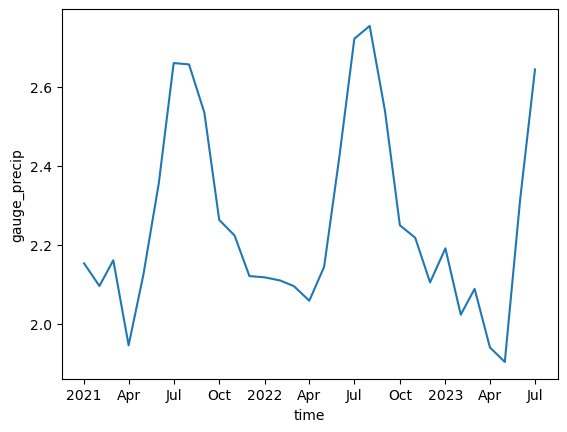

In [32]:
# plot the monthly time series
prep1=prep.gauge_precip.mean(dim=['lon','lat'])
prep1.plot()
plt.show()

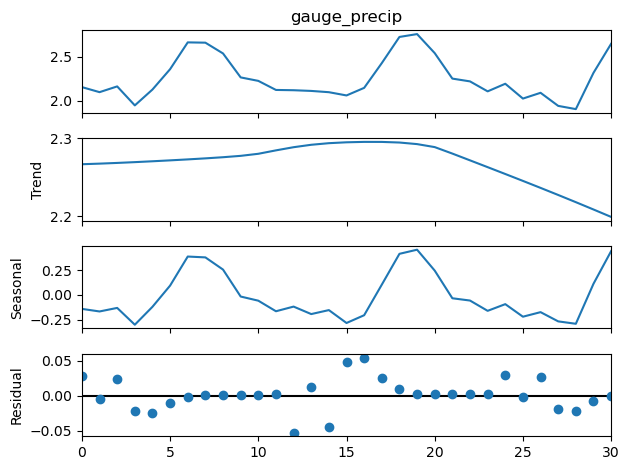

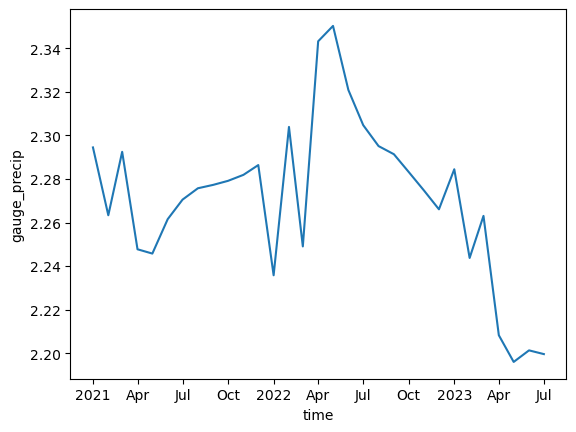

In [50]:
#用stl去季节性
stl1 = STL(prep1, seasonal = 13, period = 12)
result2 = stl1.fit()
result2.plot()
plt.show()

# 分解结果
trend1 = result2.trend
seasonal1 = result2.seasonal
residual1 = result2.resid


# 4. 去除季节性（原始数据 - 季节性成分）
deseasonalized1 = prep1 - seasonal1
deseasonalized1.plot()
plt.show()

#去季节性后，年平均降水在2.27mm/day左右上下波动，2023年4-6月降水较多，2023年4-6月降水较以往两年较少

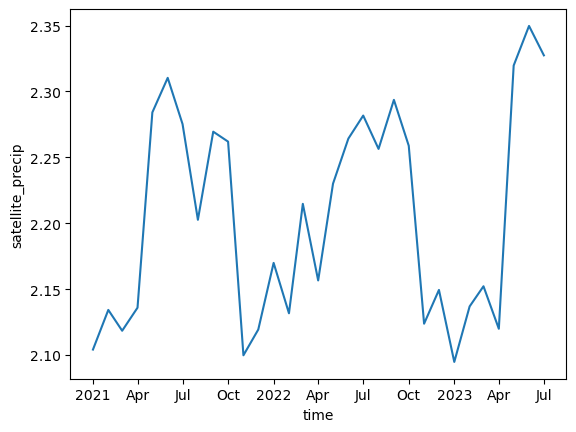

In [33]:
#3.2

#1.# plot the monthly satellite time series
prep2=prep.satellite_precip.mean(dim=['lon','lat'])
prep2.plot()
plt.show()
#趋势一样，4-10月降水更多 （为什么）
# 数值不同，有更多波动，平均温度较gauge低（猜测原因是gauge是风损调整后测得的降水量）

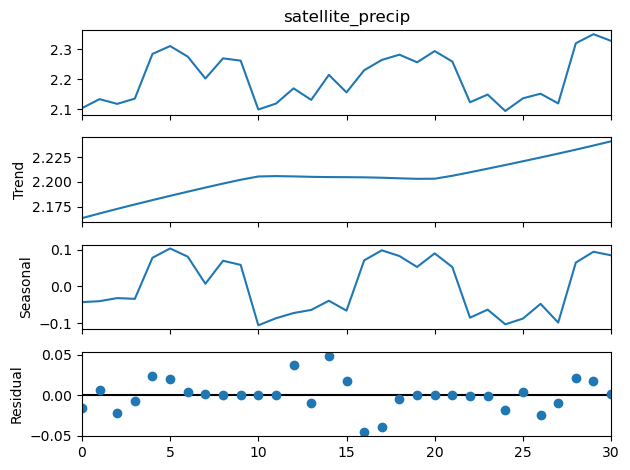

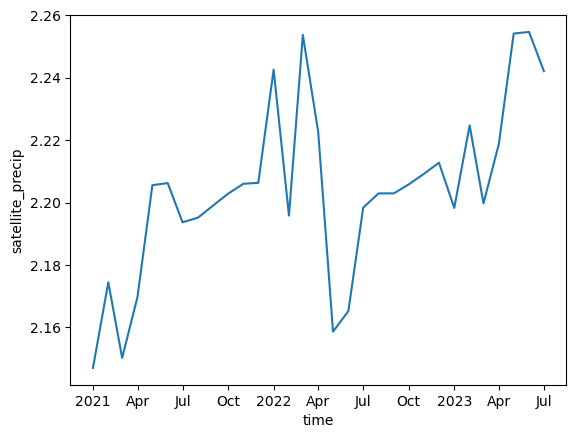

In [34]:
#2.
#用stl去季节性
stl2 = STL(prep2, seasonal = 13, period = 12)
result2 = stl2.fit()
result2.plot()
plt.show()

# 分解结果
trend2 = result2.trend
seasonal2 = result2.seasonal
residual2 = result2.resid


# 4. 去除季节性（原始数据 - 季节性成分）
deseasonalized2 = prep2 - seasonal1
deseasonalized2.plot()
plt.show()

#去季节性后，年平均降为什么还是有季节性波动？感觉trend更能显示去季节性后变化趋势

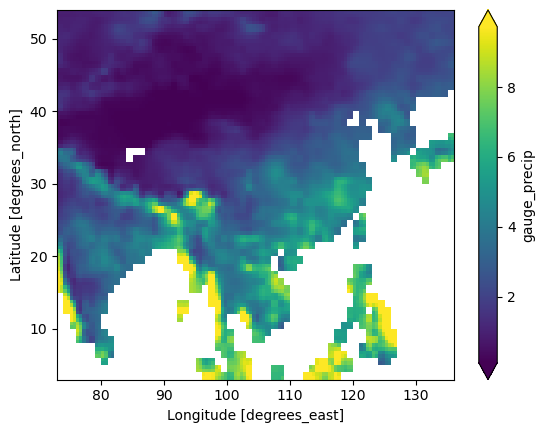

<xarray.DataArray 'gauge_precip' (time: 31, lat: 102, lon: 126)> Size: 2MB
array([[[1.086425, 1.013459, ..., 0.347114, 0.336067],
        [0.97708 , 0.913992, ..., 0.337661, 0.328132],
        ...,
        [     nan,      nan, ...,      nan,      nan],
        [     nan,      nan, ...,      nan,      nan]],

       [[1.428348, 1.379475, ..., 0.51626 , 0.545849],
        [1.318952, 1.315356, ..., 0.413955, 0.432564],
        ...,
        [     nan,      nan, ...,      nan,      nan],
        [     nan,      nan, ...,      nan,      nan]],

       ...,

       [[0.831967, 0.703216, ..., 3.765164, 3.804151],
        [0.660713, 0.553218, ..., 4.218429, 4.19065 ],
        ...,
        [     nan,      nan, ...,      nan,      nan],
        [     nan,      nan, ...,      nan,      nan]],

       [[1.012071, 1.172442, ..., 1.734776, 1.667662],
        [0.792624, 0.888948, ..., 1.48741 , 1.313099],
        ...,
        [     nan,      nan, ...,      nan,      nan],
        [     nan,      nan, ...,      nan,      nan]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 504B 73.25 73.75 74.25 74.75 ... 134.8 135.2 135.8
  * lat      (lat) float32 408B 53.75 53.25 52.75 52.25 ... 4.75 4.25 3.75 3.25
  * time     (time) datetime64[ns] 248B 2021-01-01 2021-02-01 ... 2023-07-01
Attributes:
    units:         mm/day
    long_name:     wind-loss adjusted gauge precipitation
    valid_range:   [  0. 100.]
    cell_methods:  time: mean

In [64]:
#3 mean precipitation of China
gauge_precip1 = prep.gauge_precip.sel(lon=slice(73,136),lat=slice(54,3))
gauge_precip1.mean(dim='time').plot(robust=True)
plt.show()
gauge_precip1

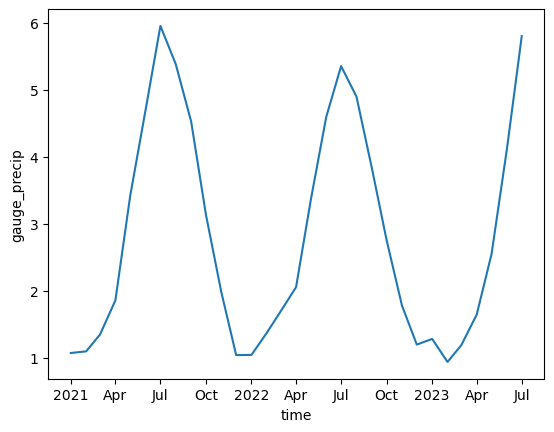

In [75]:
#4 time series precipitation of China
china = gauge_precip1.mean(dim=['lat','lon'])
china.plot()
plt.show()
#最高可达到6，最低1mm/day，峰值高，季节性差距明显，波幅度剧烈

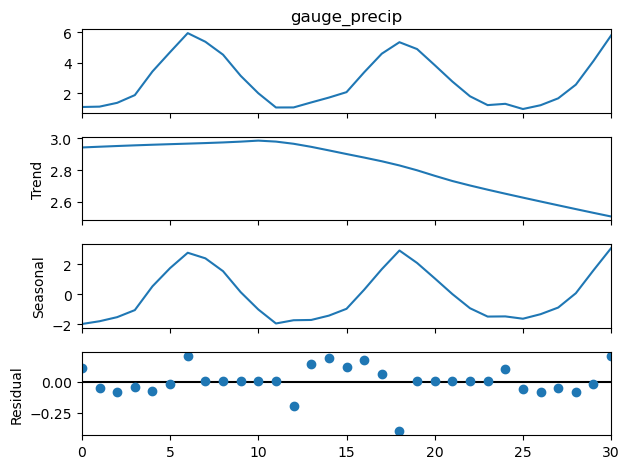

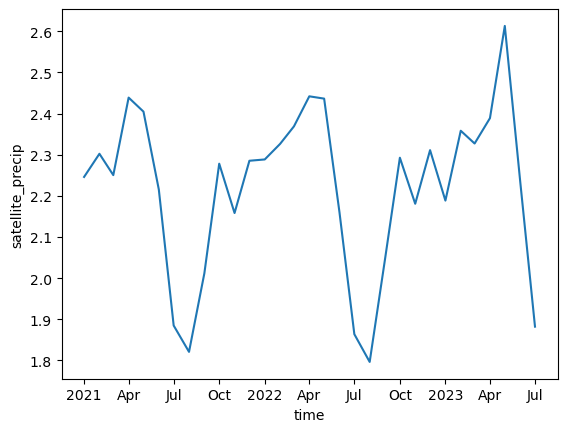

<xarray.DataArray 'satellite_precip' ()> Size: 8B
array(2.2194921)

In [71]:
#4.
#用stl去季节性
stl2 = STL(china, seasonal = 13, period = 12)
result2 = stl2.fit()
result2.plot()
plt.show()

# 分解结果
trend2 = result2.trend
seasonal2 = result2.seasonal
residual2 = result2.resid


# 4. 去除季节性（原始数据 - 季节性成分）
deseasonalized2 = prep2 - seasonal1
deseasonalized2.plot()
plt.show()
deseasonalized2.mean()
#去季节性后，年平均降为什么还是有季节性波动？感觉trend更能显示去季节性后变化趋势
#在1.8-2.4mm/day波动，有明显季节性变化，7-10月最干旱，4-7月降水最多,平均2.22mm/day。

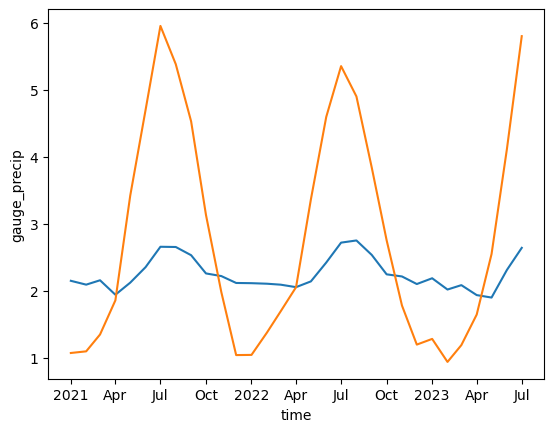

In [78]:
#compare global and Chinese gauge data
prep1.plot()
china.plot()
plt.show()
#趋势一样（为什么是北半球为全球趋势？），中国波动比全球剧烈很多（可能中国纬度较低，同时南半球数据的中和有很大影响）